# Ayoub TIR | Khalil HAOUARI - Machine Learning for DE

# imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import xarray as xr
import netCDF4
import sklearn
import statsmodels
import seaborn
import scipy
import prophet
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from itertools import product
import tensorflow as tf
Sequential    = tf.keras.models.Sequential
LSTM          = tf.keras.layers.LSTM
Dense         = tf.keras.layers.Dense
Dropout       = tf.keras.layers.Dropout
EarlyStopping = tf.keras.callbacks.EarlyStopping


/Users/ayoubtir/Desktop/Efrei/semester 8/ML for DE/project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
BASE = Path(".").resolve()

# 1. Data Loading & Preparation

## 1.1 Atmospheric CO2 — NOAA Mauna Loa (1958–2026)

In [3]:
df_co2 = pd.read_csv(BASE / "datasets/NOAA/co2_mm_mlo.csv", comment="#")

print(df_co2.shape)
print(df_co2.head())

(819, 8)
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.69     -1 -9.99 -0.99
3  1958      6     1958.4548   317.27          315.15     -1 -9.99 -0.99
4  1958      7     1958.5370   315.87          315.20     -1 -9.99 -0.99


In [4]:
for col in df_co2.columns :
  print("=" * 10)
  print(col, " :")
  print(df_co2[col].value_counts())

year  :
year
1959    12
1960    12
1961    12
1962    12
1963    12
        ..
2023    12
2024    12
2025    12
1958    10
2026     5
Name: count, Length: 69, dtype: int64
month  :
month
3     69
4     69
5     69
6     68
7     68
8     68
9     68
10    68
11    68
12    68
1     68
2     68
Name: count, dtype: int64
decimal date  :
decimal date
1958.2027    1
1958.2877    1
1958.3699    1
1958.4548    1
1958.5370    1
            ..
2026.0417    1
2026.1250    1
2026.2083    1
2026.2917    1
2026.3750    1
Name: count, Length: 819, dtype: int64
average  :
average
336.14    3
313.33    2
315.58    2
317.70    2
321.02    2
         ..
428.62    1
429.35    1
430.15    1
431.12    1
432.34    1
Name: count, Length: 795, dtype: int64
deseasonalized  :
deseasonalized
317.89    3
319.79    3
319.38    2
319.07    2
319.37    2
         ..
428.34    1
428.41    1
428.69    1
428.65    1
429.14    1
Name: count, Length: 787, dtype: int64
ndays  :
ndays
-1     195
 28     82
 29     73
 27 

The `ndays`, `sdev` and `unc` columns use -1 / -9.99 / -0.99 as missing value flags (~195 months affected). These are just quality metadata, we only need `average` and `deseasonalized` anyway so it doesn't matter.

In [5]:
df_co2["date"] = pd.to_datetime(df_co2[["year", "month"]].assign(day=1))
df_co2 = df_co2.set_index("date")[["average", "deseasonalized"]]
df_co2.columns = ["co2_ppm", "co2_deseas"]

print(f"{len(df_co2)} months loaded")
print(df_co2.head())

819 months loaded
            co2_ppm  co2_deseas
date                           
1958-03-01   315.71      314.44
1958-04-01   317.45      315.16
1958-05-01   317.51      314.69
1958-06-01   317.27      315.15
1958-07-01   315.87      315.20


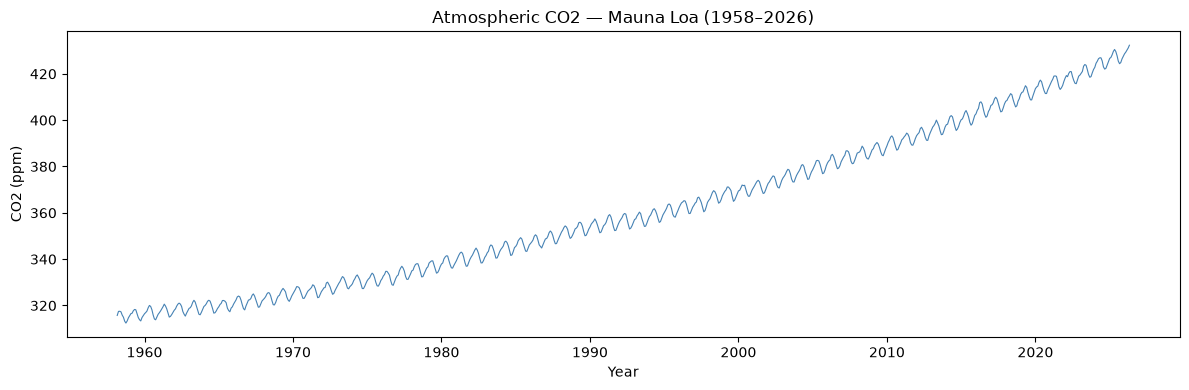

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_co2.index, df_co2["co2_ppm"], color="steelblue", linewidth=0.8)
plt.title("Atmospheric CO2 — Mauna Loa (1958–2026)")
plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")
plt.tight_layout()
plt.show()


Two things jump out :

1. **Clear upward trend** — CO2 went from ~315 ppm in 1958 to 420+ ppm today, roughly +30% in 67 years.

2. **Annual cycle** — the saw-tooth pattern comes from Northern Hemisphere vegetation: plants absorb CO2 in summer and release it in winter.

## 1.2 Temperature — ERA5 France (1940–2025)

In [7]:
ds = xr.open_dataset(BASE / "datasets/era5_france_1940_2025/data_stream-moda_stepType-avgua.nc")

print(ds)

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 1032, latitude: 45, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
    expver      (valid_time) <U4 17kB ...
  * latitude    (latitude) float64 360B 52.0 51.75 51.5 ... 41.5 41.25 41.0
  * longitude   (longitude) float64 488B -5.0 -4.75 -4.5 -4.25 ... 9.5 9.75 10.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 11MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-12T17:02 GRIB to CDM+CF via cfgrib-0.9.1...


The dataset has temperature at 2 meters (t2m) per date, latitude and longitude. We'll average over the whole France grid to get a single monthly temperature series.

### Temperature map — first month of the dataset

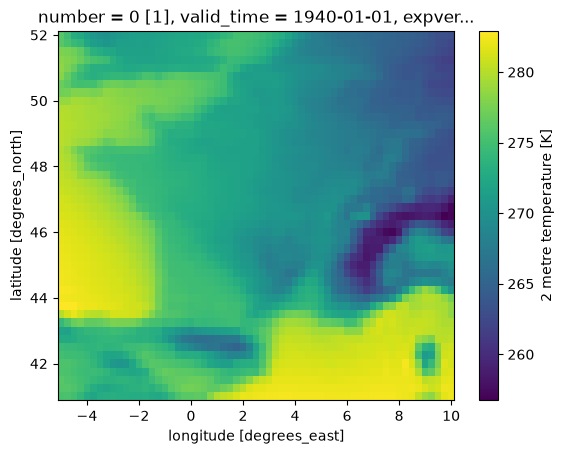

In [8]:
ds["t2m"].isel(valid_time=0).plot()
plt.show()

In [9]:
# kelvin to celsius + spatial average over France
t2m_france = (ds["t2m"] - 273.15).mean(dim=["latitude", "longitude"])

df_temp = t2m_france.to_series().rename("temp_celsius")
df_temp.index = pd.to_datetime(df_temp.index).to_period("M").to_timestamp()
df_temp.index.name = "date"

print(f"{len(df_temp)} months")
print(df_temp.head())

Number of points   : 1032
date
1940-01-01    -0.268454
1940-02-01     4.231189
1940-03-01     6.878069
1940-04-01     9.541975
1940-05-01    13.469721
Freq: MS, Name: temp_celsius, dtype: float32


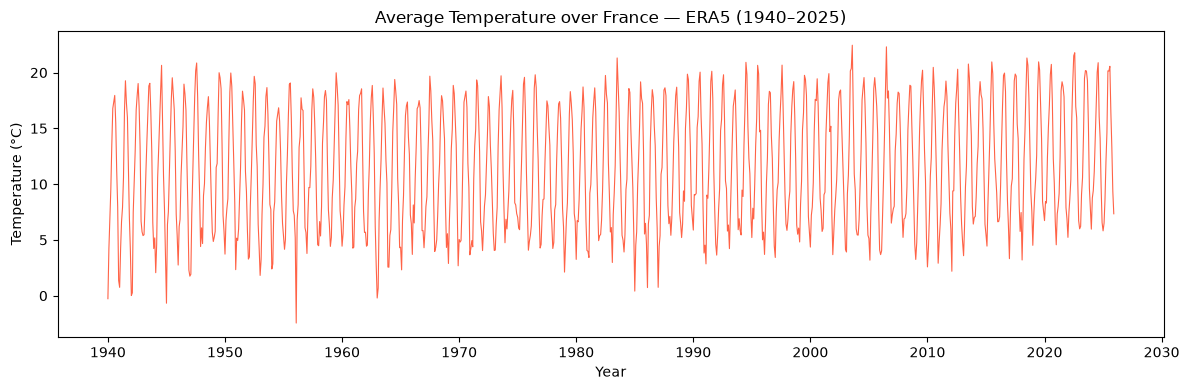

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df_temp.index, df_temp.values, color="tomato", linewidth=0.8)
plt.title("Average Temperature over France — ERA5 (1940–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

Two things to note :

1. **Strong seasonality** — temperature swings between ~0-5°C in winter and 18-22°C in summer every year.

2. **Warming trend** — recent summers (2000-2025) tend to be hotter than in the 1940s-60s, especially visible from the 1990s onward.

## 1.3 Sea Level — University of Colorado (1993–2026)

In [11]:
df_sl = pd.read_csv(BASE / "datasets/sea_level_cu_2026rel1.csv", index_col="date", parse_dates=True)

In [12]:
df_sl.describe()

,sea_level_mm
count,399.000000
mean,35.714714
std,32.466183
min,-21.169000
25%,8.887667
50%,28.830000
75%,63.278000
max,95.331000


In [13]:
df_sl.index = pd.to_datetime(df_sl.index).to_period("M").to_timestamp()
df_sl.index.name = "date"

print(f"{df_sl.index.min().date()} → {df_sl.index.max().date()}, {len(df_sl)} months")
print(df_sl.head())

Périod  : 1992-12-01 ==> 2026-02-01
Points   : 399
            sea_level_mm
date                    
1992-12-01    -18.121500
1993-01-01    -21.169000
1993-02-01    -19.278333
1993-03-01    -16.197667
1993-04-01    -15.392500


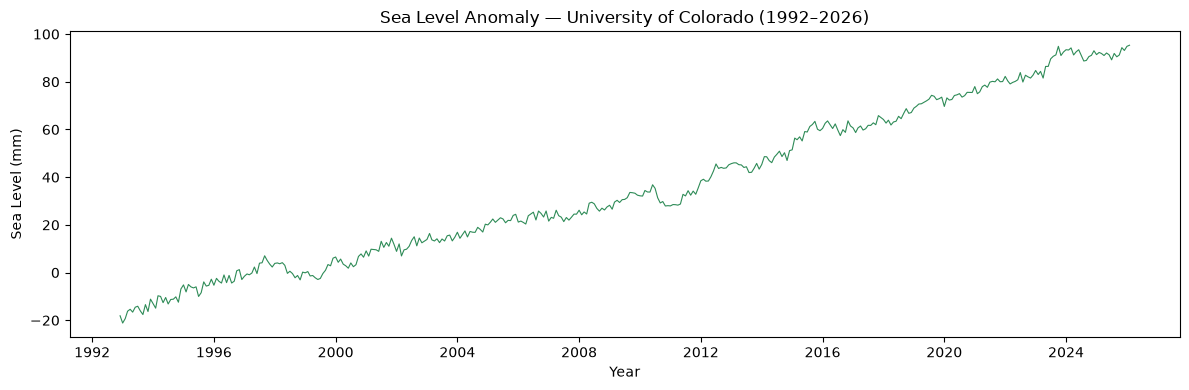

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(df_sl.index, df_sl["sea_level_mm"], color="seagreen", linewidth=0.8)
plt.title("Sea Level Anomaly — University of Colorado (1992–2026)")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.tight_layout()
plt.show()

Pretty clear upward trend — about 100 mm (10 cm) of rise since 1993, steady and almost linear.

## 1.4 Merging the 3 datasets — common period 1993–2025

In [15]:
df = pd.concat([df_co2["co2_ppm"], df_temp, df_sl], axis=1).loc["1993":"2025"]
df = df.dropna()

print(f"{df.index.min().date()} → {df.index.max().date()}, {len(df)} months")
print(f"columns : {list(df.columns)}")
print()
print(df.describe().round(2))

Périod  : 1993-01-01 ==> 2025-12-01
Points   : 396 month
Columns : ['co2_ppm', 'temp_celsius', 'sea_level_mm']

       co2_ppm  temp_celsius  sea_level_mm
count   396.00        396.00        396.00
mean    389.49         12.14         35.55
std      20.80          5.28         32.20
min     354.14          2.19        -21.17
25%     371.14          7.39          8.89
50%     387.66         12.04         28.79
75%     407.38         17.08         62.87
max     430.51         22.45         94.87


## 2. Exploratory Data Analysis (EDA)

In [16]:
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

### Correlation matrix

In [17]:
corr = df.corr()

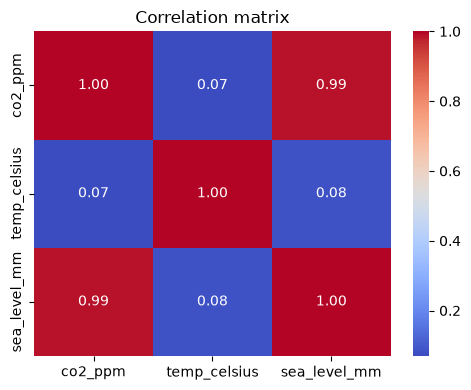

In [18]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

CO2 and sea level are almost perfectly correlated (0.99) — both just follow the same long-term trend over 30 years. Temperature correlation is lower because the annual cycle dominates.

### Evolution of the 3 variables (normalized)

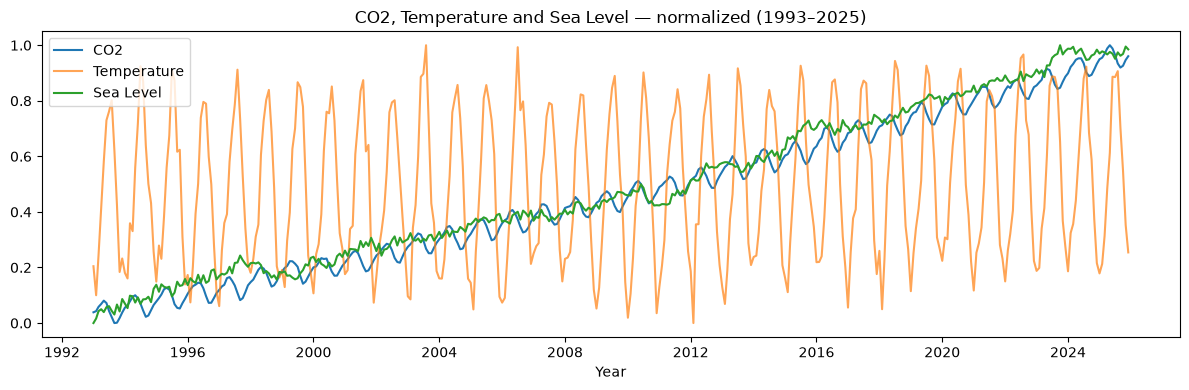

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(df_norm.index, df_norm["co2_ppm"], label="CO2")
plt.plot(df_norm.index, df_norm["temp_celsius"], label="Temperature", alpha=0.7)
plt.plot(df_norm.index, df_norm["sea_level_mm"], label="Sea Level")
plt.title("CO2, Temperature and Sea Level — normalized (1993–2025)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

CO2 and sea level track each other closely — both rise steadily 1993→2025. Temperature oscillates a lot due to seasonality so its trend is harder to see here.

### Seasonal decomposition — temperature

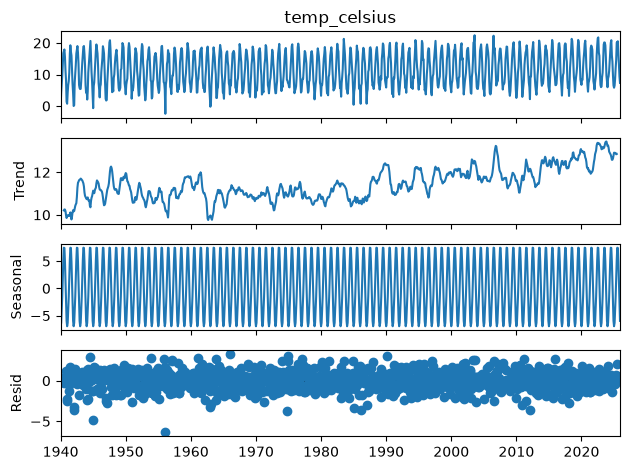

In [20]:
result = seasonal_decompose(df_temp, model="additive", period=12)
result.plot()
plt.tight_layout()
plt.show()

The decomposition separates 3 components :

- **Trend** : slow warming from ~10.5°C in 1940 to ~13°C in 2025, acceleration visible after the 1990s.
- **Seasonal** : very regular ±6°C annual cycle, stable over the whole 85-year period.
- **Residual** : mostly noise around 0, with a few outliers — the cold winters of 1956 and 1963 show up clearly.

### 2.4 Stationarity Test — Augmented Dickey-Fuller (ADF)

In [21]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF — {name}")
    print(f"  stat={result[0]:.4f}  p={result[1]:.4f}  → {'stationary' if result[1] < 0.05 else 'non-stationary'}")
    print()

adf_test(df["temp_celsius"],          "temp (raw)")
adf_test(df["temp_celsius"].diff(12), "temp (seasonal diff, lag=12)")
adf_test(df["co2_ppm"],               "CO2 (raw)")
adf_test(df["co2_ppm"].diff(),        "CO2 (1st diff)")

--- ADF Test : Temperature (raw) ---
ADF Statistic : -3.4594
p-value       : 0.0091
  Critical Value 1% : -3.4476
  Critical Value 5% : -2.8692
  Critical Value 10% : -2.5708
=> Stationary ✓  (α = 0.05)

--- ADF Test : Temperature (seasonal diff, lag=12) ---
ADF Statistic : -6.6770
p-value       : 0.0000
  Critical Value 1% : -3.4481
  Critical Value 5% : -2.8694
  Critical Value 10% : -2.5709
=> Stationary ✓  (α = 0.05)

--- ADF Test : CO2 (raw) ---
ADF Statistic : 2.1899
p-value       : 0.9989
  Critical Value 1% : -3.4476
  Critical Value 5% : -2.8692
  Critical Value 10% : -2.5708
=> Non-stationary ✗  (α = 0.05)

--- ADF Test : CO2 (1st diff) ---
ADF Statistic : -4.3952
p-value       : 0.0003
  Critical Value 1% : -3.4476
  Critical Value 5% : -2.8692
  Critical Value 10% : -2.5708
=> Stationary ✓  (α = 0.05)



**Takeaways :**
- Temperature (raw) : ADF detects stationarity because of the oscillation, but the warming trend is real — seasonal differencing (D=1, s=12) still needed.
- CO2 (raw) : non-stationary as expected. First difference makes it stationary → **d=1**.
- We'll search over **(p, 1, q)(P, 1, Q)[12]** for both.

### 2.5 ACF / PACF — Temperature

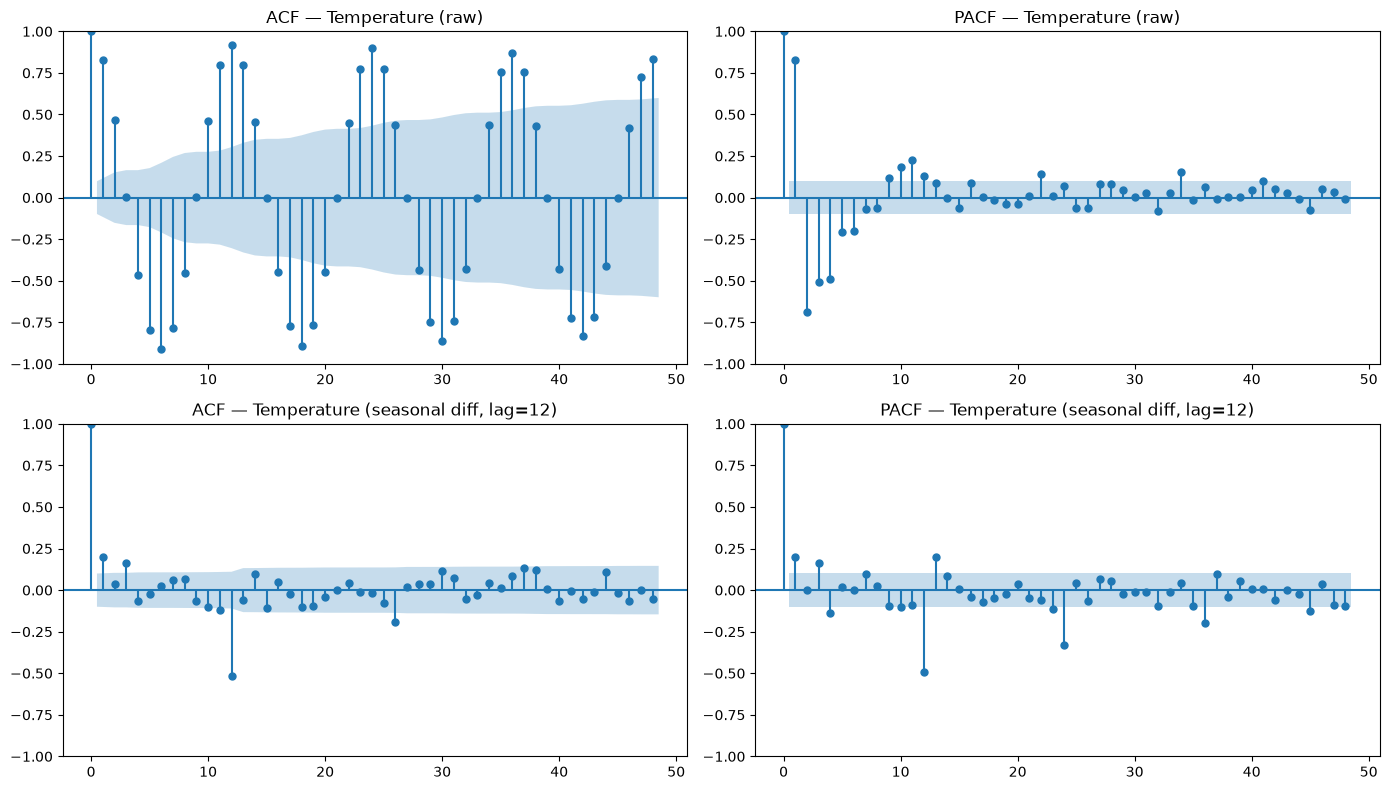

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df["temp_celsius"], lags=48, ax=axes[0, 0], title="ACF — Temperature (raw)")
plot_pacf(df["temp_celsius"], lags=48, ax=axes[0, 1], title="PACF — Temperature (raw)")

temp_diff12 = df["temp_celsius"].diff(12).dropna()
plot_acf(temp_diff12, lags=48, ax=axes[1, 0], title="ACF — Temperature (seasonal diff, lag=12)")
plot_pacf(temp_diff12, lags=48, ax=axes[1, 1], title="PACF — Temperature (seasonal diff, lag=12)")

plt.tight_layout()
plt.show()

- **Raw temperature** : big spikes at lags 12, 24, 36 → confirms annual cycle → **s=12, D=1** for SARIMA.
- **After seasonal diff** : remaining spikes at low lags guide (p, q), spikes at 12/24 guide (P, Q).

### 2.6 Cross-correlation CO2 → Temperature (with lag)

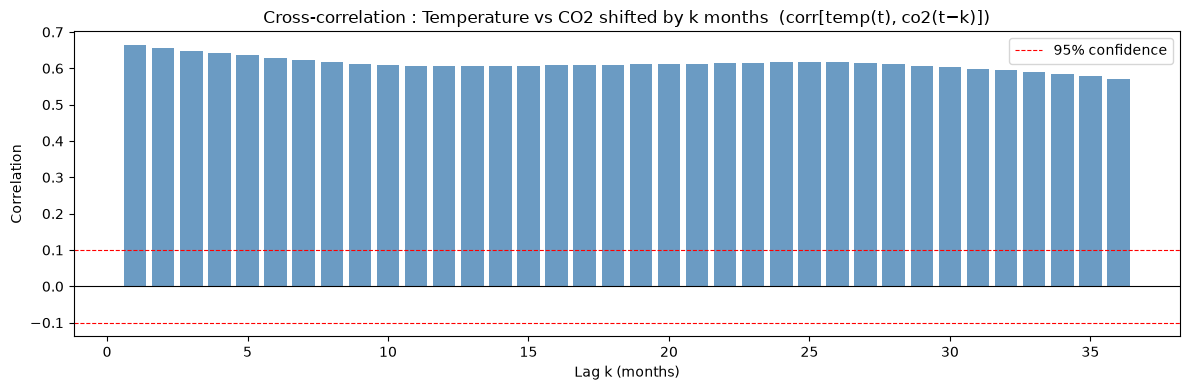

In [23]:
from statsmodels.tsa.stattools import ccf

# deseasonalize with 12-month rolling mean
temp_trend = df["temp_celsius"].rolling(12, center=True).mean().dropna()
co2_aligned = df["co2_ppm"].reindex(temp_trend.index).dropna()
idx = temp_trend.index.intersection(co2_aligned.index)

temp_z = (temp_trend[idx] - temp_trend[idx].mean()) / temp_trend[idx].std()
co2_z  = (co2_aligned[idx] - co2_aligned[idx].mean()) / co2_aligned[idx].std()

nlags = 36
ccf_vals = ccf(temp_z, co2_z, nlags=nlags)
conf_bound = 1.96 / np.sqrt(len(idx))

plt.figure(figsize=(12, 4))
plt.bar(np.arange(1, len(ccf_vals) + 1), ccf_vals, color="steelblue", alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.axhline( conf_bound, color="red", linestyle="--", linewidth=0.8, label="95% confidence")
plt.axhline(-conf_bound, color="red", linestyle="--", linewidth=0.8)
plt.title("Cross-correlation : Temperature vs CO2 shifted by k months  (corr[temp(t), co2(t−k)])")
plt.xlabel("Lag k (months)")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()

**Results :**
- High correlation at all lags — CO2 and deseasonalized temperature share the same long-term upward trend.
- No sharp peak at a specific lag, so CO2 isn't a short-term predictor. The effect is structural and accumulates over decades.
- → We'll use CO2 as an **exogenous regressor in Prophet** to capture the shared trend.

## 3. Modelling

### 3.1 Train / Test split

In [24]:
train = df.loc["1993":"2015"]
test  = df.loc["2016":"2025"]

print(f"train : {train.index.min().date()} → {train.index.max().date()} ({len(train)} months)")
print(f"test  : {test.index.min().date()} → {test.index.max().date()} ({len(test)} months)")

Train : 1993-01-01 ==> 2015-12-01  (276 months)
Test  : 2016-01-01 ==> 2025-12-01  (120 months)


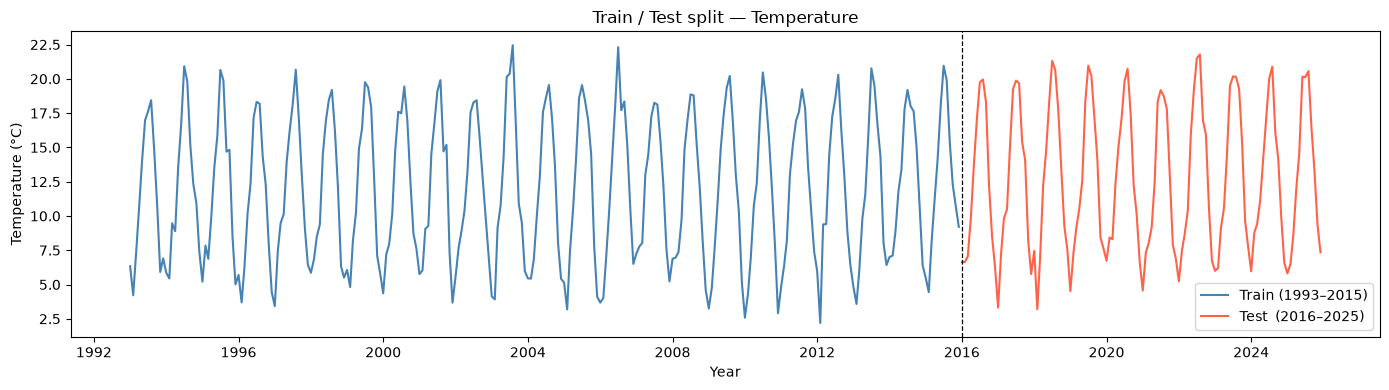

In [25]:
plt.figure(figsize=(14, 4))
plt.plot(train.index, train["temp_celsius"], label="Train (1993–2015)", color="steelblue")
plt.plot(test.index,  test["temp_celsius"],  label="Test  (2016–2025)", color="tomato")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.9)
plt.title("Train / Test split — Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 SARIMA

From the ADF and ACF/PACF :
- d=1 (non-seasonal diff), D=1 s=12 (seasonal diff)
- Grid search over (p, q, P, Q), pick the model with lowest AIC

In [26]:
best_aic   = np.inf
best_order = None
best_fit   = None

for p in [0, 1, 2]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    mdl = SARIMAX(train["temp_celsius"],
                                  order=(p, 1, q),
                                  seasonal_order=(P, 1, Q, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
                    res = mdl.fit(disp=False)
                    if res.aic < best_aic:
                        best_aic   = res.aic
                        best_order = (p, 1, q, P, 1, Q)
                        best_fit   = res
                except Exception:
                    continue

In [27]:
p, d, q, P, D, Q = best_order
print(f"best order : SARIMA({p},{d},{q})({P},{D},{Q})[12]  AIC={best_aic:.2f}")

Best order : SARIMA(1,1,1)(0,1,1)[12]
AIC        : 830.16


In [28]:
sarima_forecast = best_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

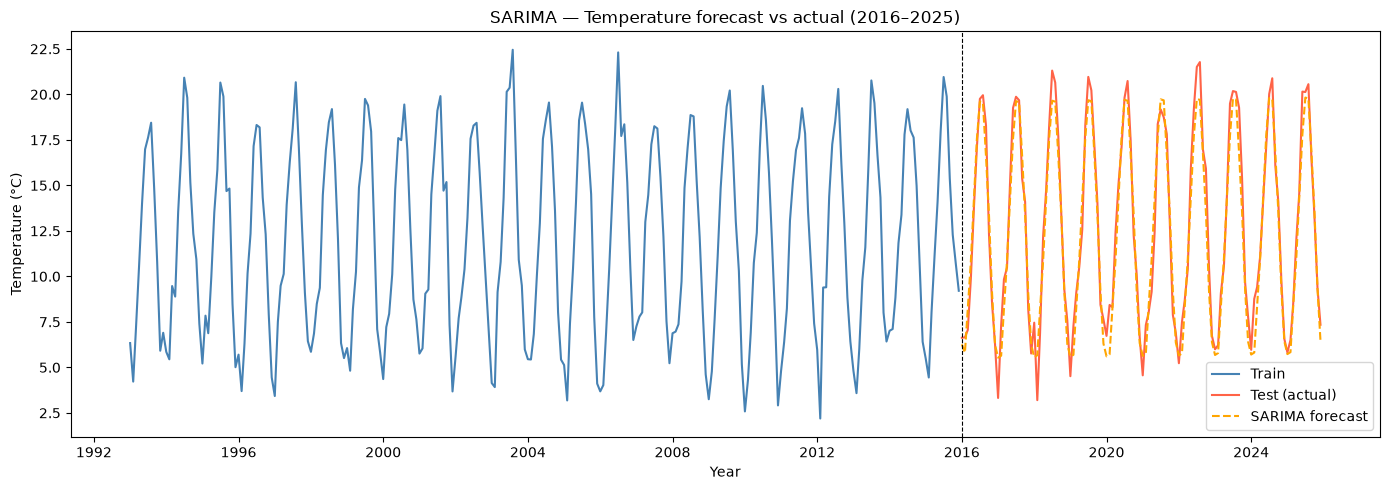

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["temp_celsius"], label="Train",           color="steelblue")
plt.plot(test.index,  test["temp_celsius"],  label="Test (actual)",   color="tomato")
plt.plot(test.index,  sarima_forecast,       label="SARIMA forecast", color="orange", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("SARIMA — Temperature forecast vs actual (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
mae  = mean_absolute_error(test["temp_celsius"], sarima_forecast)
rmse = np.sqrt(mean_squared_error(test["temp_celsius"], sarima_forecast))
mape = np.mean(np.abs((test["temp_celsius"] - sarima_forecast) / test["temp_celsius"])) * 100

print(f"SARIMA  →  MAE={mae:.4f}°C  RMSE={rmse:.4f}°C  MAPE={mape:.2f}%")

--- SARIMA — Test set metrics (2016–2025) ---
MAE  : 0.9078 °C
RMSE : 1.1223 °C
MAPE : 9.12 %


### 3.3 Prophet - With CO2 emission as exogeneous variable

In [31]:
train_prophet = train[["temp_celsius", "co2_ppm"]].reset_index().rename(
    columns={"date": "ds", "temp_celsius": "y"}
)
test_prophet = test[["temp_celsius", "co2_ppm"]].reset_index().rename(
    columns={"date": "ds", "temp_celsius": "y"}
)

In [32]:
mdl_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mdl_prophet.add_regressor("co2_ppm")
mdl_prophet.fit(train_prophet)

00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:21 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
# CO2 values for the test period are already known, just pass them to Prophet
future = test_prophet[["ds", "co2_ppm"]]
prophet_fc = mdl_prophet.predict(future)

In [34]:
prophet_forecast = pd.Series(prophet_fc["yhat"].values, index=test.index)

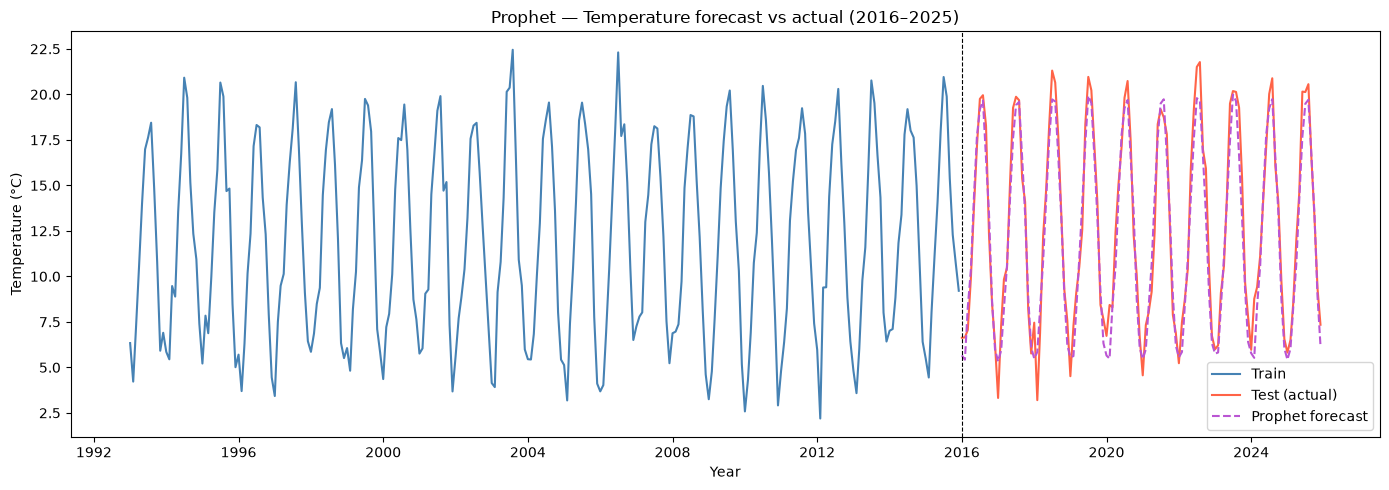

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["temp_celsius"],  label="Train",            color="steelblue")
plt.plot(test.index,  test["temp_celsius"],   label="Test (actual)",    color="tomato")
plt.plot(test.index,  prophet_forecast,       label="Prophet forecast", color="mediumorchid", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("Prophet — Temperature forecast vs actual (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
mae_p  = mean_absolute_error(test["temp_celsius"], prophet_forecast)
rmse_p = np.sqrt(mean_squared_error(test["temp_celsius"], prophet_forecast))
mape_p = np.mean(np.abs((test["temp_celsius"] - prophet_forecast) / test["temp_celsius"])) * 100

In [37]:
print(f"Prophet  →  MAE={mae_p:.4f}°C  RMSE={rmse_p:.4f}°C  MAPE={mape_p:.2f}%")

--- Prophet — Test set metrics (2016–2025) ---
MAE  : 0.9670 °C
RMSE : 1.1716 °C
MAPE : 9.59 %


### 3.4 Comparison — SARIMA vs Prophet

In [38]:
print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 40)
print(f"{'SARIMA':<12} {mae:>7.4f}  {rmse:>7.4f}  {mape:>6.2f}%")
print(f"{'Prophet':<12} {mae_p:>7.4f}  {rmse_p:>7.4f}  {mape_p:>6.2f}%")

Model             MAE     RMSE     MAPE
----------------------------------------
SARIMA        0.9078   1.1223    9.12%
Prophet       0.9670   1.1716    9.59%


### 3.5 Prophet without CO2 regressor

In [39]:
mdl_prophet_base = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mdl_prophet_base.fit(train_prophet)

00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:21 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
prophet_base_fc = mdl_prophet_base.predict(test_prophet[["ds"]])
prophet_base_forecast = pd.Series(prophet_base_fc["yhat"].values, index=test.index)


In [41]:
mae_pb  = mean_absolute_error(test["temp_celsius"], prophet_base_forecast)
rmse_pb = np.sqrt(mean_squared_error(test["temp_celsius"], prophet_base_forecast))

In [42]:
print(f"Prophet (no CO2)  →  MAE={mae_pb:.4f}°C  RMSE={rmse_pb:.4f}°C")
print(f"Prophet (w/ CO2)  →  MAE={mae_p:.4f}°C")
print(f"CO2 regressor {'helped' if mae_p < mae_pb else 'did not help'}")

--- Prophet (no CO2) — Test set metrics ---
MAE  : 0.9128 °C
RMSE : 1.1182 °C

Prophet with CO2 :  MAE = 0.9670 °C
=> CO2 regressor did not help ✗


### 3.6 Prophet grid search on hyperparameters

Two main hyperparameters to tune :
- `changepoint_prior_scale` : how flexible the trend is. Too low = rigid, too high = overfitting.
- `seasonality_mode` : additive (constant amplitude) vs multiplicative (amplitude scales with trend).
- `seasonality_prior_scale` : how much the seasonality is allowed to vary.

In [43]:
param_grid = {
    "changepoint_prior_scale" : [0.01, 0.1, 0.3, 0.5],
    "seasonality_prior_scale" : [1.0, 10.0],
    "seasonality_mode"        : ["additive", "multiplicative"],
}

In [44]:
keys   = list(param_grid.keys())
values = list(param_grid.values())

In [45]:
best_mae_p   = np.inf
best_params  = None
best_prophet = None

In [46]:
for combo in product(*values):
    params = dict(zip(keys, combo))
    try:
        m = Prophet(**params, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.add_regressor("co2_ppm")
        m.fit(train_prophet)
        fc = m.predict(test_prophet[["ds", "co2_ppm"]])
        mae_i = mean_absolute_error(test["temp_celsius"], fc["yhat"].values)
        if mae_i < best_mae_p:
            best_mae_p   = mae_i
            best_params  = params
            best_prophet = m
            best_fc      = fc
    except Exception:
        continue

00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:21 - cmdstanpy - INFO - Chain [1] done processing
00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:21 - cmdstanpy - INFO - Chain [1] done processing
00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:21 - cmdstanpy - INFO - Chain [1] done processing
00:55:21 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1] done processing
00:55:22 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1] done processing
00:55:22 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1] done processing
00:55:22 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1] done processing
00:55:22 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1] done processing
00:55:22 - cmdstanpy - INFO - Chain [1] start processing
00:55:22 - cmdstanpy - INFO - Chain [1]

In [47]:
print("best params :")
for k, v in best_params.items():
    print(f"  {k} = {v}")
print(f"best MAE : {best_mae_p:.4f}°C  (default : {mae_p:.4f}°C)")

Best hyperparameters :
  changepoint_prior_scale : 0.1
  seasonality_prior_scale : 1.0
  seasonality_mode : additive

Best MAE : 0.8445 °C  (vs 0.9670 °C default Prophet)


In [48]:
prophet_best_forecast = pd.Series(best_fc["yhat"].values, index=test.index)

In [49]:
rmse_best = np.sqrt(mean_squared_error(test["temp_celsius"], prophet_best_forecast))
mape_best = np.mean(np.abs((test["temp_celsius"] - prophet_best_forecast) / test["temp_celsius"])) * 100

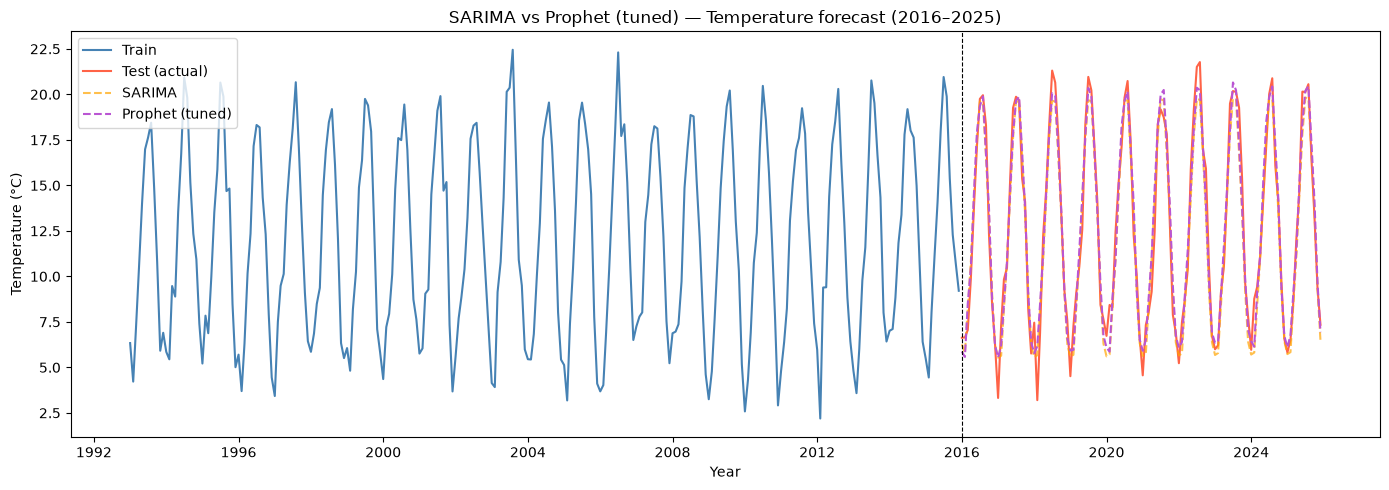

In [50]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["temp_celsius"],      label="Train",                  color="steelblue")
plt.plot(test.index,  test["temp_celsius"],       label="Test (actual)",          color="tomato")
plt.plot(test.index,  sarima_forecast,            label="SARIMA",                 color="orange",       linestyle="--", alpha=0.7)
plt.plot(test.index,  prophet_best_forecast,      label="Prophet (tuned)",        color="mediumorchid", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("SARIMA vs Prophet (tuned) — Temperature forecast (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.7 Final comparison — all models

In [51]:
models = [
    ("SARIMA(1,1,1)(0,1,1)[12]",  mae,    rmse,    mape),
    ("Prophet (no CO2)",           mae_pb, rmse_pb, None),
    ("Prophet (CO2, default)",     mae_p,  rmse_p,  mape_p),
    ("Prophet (CO2, tuned)",       best_mae_p, rmse_best, mape_best),
]

In [52]:
print(f"{'Model':<32} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 60)
for name, m, r, mp in models:
    mape_str = f"{mp:>7.2f}%" if mp is not None else "     N/A"
    print(f"{name:<32} {m:>7.4f}  {r:>7.4f}  {mape_str}")

Model                                 MAE     RMSE     MAPE
------------------------------------------------------------
SARIMA(1,1,1)(0,1,1)[12]          0.9078   1.1223     9.12%
Prophet (no CO2)                  0.9128   1.1182       N/A
Prophet (CO2, default)            0.9670   1.1716     9.59%
Prophet (CO2, tuned)              0.8445   1.0514     8.84%


### 3.8 Re-training on full temperature history (1940–2025)

Before, we were limited to 1993-2015 because of the CO2/sea level data constraint. Here we use the full ERA5 series :
- **SARIMA** : train on 1940-2015 (912 months)
- **Prophet (no CO2)** : train on 1940-2015
- **Prophet + CO2** : train on 1958-2015 (CO2 only goes back to 1958)

In [53]:
train_full = df_temp.loc[:"2015"]
test_full  = df_temp.loc["2016":"2025"]

In [54]:
df_ext = pd.concat([df_co2["co2_ppm"], df_temp], axis=1).loc["1958":"2015"].dropna()
df_ext_test = pd.concat([df_co2["co2_ppm"], df_temp], axis=1).loc["2016":"2025"].dropna()
print(f"train with CO2 : {df_ext.index.min().date()} → {df_ext.index.max().date()} ({len(df_ext)} months)")


Train (with CO2) : 1958-03-01 → 2015-12-01  (694 months)


In [55]:
best_aic_full   = np.inf
best_order_full = None
best_fit_full   = None

In [56]:
for p in [0, 1, 2]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    mdl = SARIMAX(train_full,
                                  order=(p, 1, q),
                                  seasonal_order=(P, 1, Q, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
                    res = mdl.fit(disp=False)
                    if res.aic < best_aic_full:
                        best_aic_full   = res.aic
                        best_order_full = (p, 1, q, P, 1, Q)
                        best_fit_full   = res
                except Exception:
                    continue

In [57]:
p2, d2, q2, P2, D2, Q2 = best_order_full
print(f"best order : SARIMA({p2},{d2},{q2})({P2},{D2},{Q2})[12]  AIC={best_aic_full:.2f}")

Best order : SARIMA(1,1,1)(0,1,1)[12]
AIC        : 2958.66


In [58]:
sarima_full_forecast = best_fit_full.forecast(steps=len(test_full))
sarima_full_forecast.index = test_full.index

In [59]:
mae_sf  = mean_absolute_error(test_full, sarima_full_forecast)
rmse_sf = np.sqrt(mean_squared_error(test_full, sarima_full_forecast))
print(f"MAE={mae_sf:.4f}°C  (was {mae:.4f} with 1993-2015)")
print(f"RMSE={rmse_sf:.4f}°C  (was {rmse:.4f})")


MAE  : 0.8967 °C  (vs 0.9078 with 1993–2015 train)
RMSE : 1.1134 °C  (vs 1.1223 with 1993–2015 train)


In [60]:
train_full_df = train_full.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})

In [61]:
mdl_p_full = Prophet(changepoint_prior_scale=0.1,
                     seasonality_prior_scale=1.0,
                     seasonality_mode="additive",
                     yearly_seasonality=True,
                     weekly_seasonality=False,
                     daily_seasonality=False)
mdl_p_full.fit(train_full_df)

00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing


In [62]:
test_full_df = test_full.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})
fc_full = mdl_p_full.predict(test_full_df[["ds"]])
prophet_full_forecast = pd.Series(fc_full["yhat"].values, index=test_full.index)

In [63]:
mae_pf  = mean_absolute_error(test_full, prophet_full_forecast)
rmse_pf = np.sqrt(mean_squared_error(test_full, prophet_full_forecast))
print(f"Prophet (no CO2, full history)  MAE={mae_pf:.4f}°C  RMSE={rmse_pf:.4f}°C")
print(f"vs 1993-2015 train : MAE={mae_pb:.4f}°C")

Prophet (no CO2, full train)  MAE : 0.9030 °C  (vs 0.9128 with 1993–2015 train)
                             RMSE : 1.1145 °C


In [64]:
train_ext_df = df_ext.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})
test_ext_df  = df_ext_test.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})

In [65]:
best_mae_ext    = np.inf
best_params_ext = None
best_fc_ext     = None

In [66]:
for combo in product(*values):
    params = dict(zip(keys, combo))
    try:
        m = Prophet(**params, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.add_regressor("co2_ppm")
        m.fit(train_ext_df)
        fc = m.predict(test_ext_df[["ds", "co2_ppm"]])
        mae_i = mean_absolute_error(test_full, fc["yhat"].values)
        if mae_i < best_mae_ext:
            best_mae_ext    = mae_i
            best_params_ext = params
            best_fc_ext     = fc
    except Exception:
        continue

00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:36 - cmdstanpy - INFO - Chain [1] done processing
00:55:36 - cmdstanpy - INFO - Chain [1] start processing
00:55:37 - cmdstanpy - INFO - Chain [1]

In [67]:
print("best params (1958-2015 train) :")
for k, v in best_params_ext.items():
    print(f"  {k} = {v}")
print(f"best MAE : {best_mae_ext:.4f}°C  (vs {best_mae_p:.4f} with 1993-2015)")

Best hyperparameters (1958–2015 train) :
  changepoint_prior_scale : 0.01
  seasonality_prior_scale : 1.0
  seasonality_mode : multiplicative

Best MAE : 0.8370 °C  (vs 0.8445 °C with 1993–2015 train)


In [68]:
prophet_ext_forecast = pd.Series(best_fc_ext["yhat"].values, index=test_full.index)

In [69]:
mae_pe  = mean_absolute_error(test_full, prophet_ext_forecast)
rmse_pe = np.sqrt(mean_squared_error(test_full, prophet_ext_forecast))
print(f"Prophet (CO2, 1958-2015)  MAE={mae_pe:.4f}°C  RMSE={rmse_pe:.4f}°C")
print(f"vs 1993-2015 train : MAE={best_mae_p:.4f}°C")

Prophet (CO2, 1958–2015 train)  MAE : 0.8370 °C  (vs 0.8445 with 1993–2015 train)
                               RMSE : 1.0582 °C


In [70]:
print(f"{'Model':<38} {'Train from':>12} {'MAE':>8} {'RMSE':>8}")
print("-" * 70)
print(f"{'SARIMA (baseline)':<38} {'1993':>12} {mae:>7.4f}  {rmse:>7.4f}")
print(f"{'Prophet (no CO2)':<38} {'1993':>12} {mae_pb:>7.4f}  {rmse_pb:>7.4f}")
print(f"{'Prophet (CO2, tuned)':<38} {'1993':>12} {best_mae_p:>7.4f}  {rmse_best:>7.4f}")
print("-" * 70)
print(f"{'SARIMA (full history)':<38} {'1940':>12} {mae_sf:>7.4f}  {rmse_sf:>7.4f}")
print(f"{'Prophet (no CO2, full history)':<38} {'1940':>12} {mae_pf:>7.4f}  {rmse_pf:>7.4f}")
print(f"{'Prophet (CO2, tuned, extended)':<38} {'1958':>12} {mae_pe:>7.4f}  {rmse_pe:>7.4f}")

Model                                    Train from      MAE     RMSE
----------------------------------------------------------------------
SARIMA (baseline)                              1993  0.9078   1.1223
Prophet (no CO2)                               1993  0.9128   1.1182
Prophet (CO2, tuned)                           1993  0.8445   1.0514
----------------------------------------------------------------------
SARIMA (full history)                          1940  0.8967   1.1134
Prophet (no CO2, full history)                 1940  0.9030   1.1145
Prophet (CO2, tuned, extended)                 1958  0.8370   1.0582


### 3.9 LSTM

Train on 1940-2015 (full temperature series). Forecast is recursive: predict one step at a time, feed it back as input, repeat 120 times for 10 years.

In [71]:
WINDOW = 24

In [72]:
train_vals = train_full.values.reshape(-1, 1)
test_vals  = test_full.values.reshape(-1, 1)

In [73]:
scaler_lstm = MinMaxScaler()
train_scaled = scaler_lstm.fit_transform(train_vals)

In [74]:
def make_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

In [75]:
X_train, y_train = make_sequences(train_scaled, WINDOW)
print(f"X_train : {X_train.shape}  ({X_train.shape[0]} sequences × {WINDOW} months)")

X_train shape : (888, 24, 1)  ==>  888 sequences of 24 months


In [76]:
tf_seed = 42
tf.random.set_seed(tf_seed)
np.random.seed(tf_seed)

In [77]:
param_grid_lstm = {
    "window"  : [12, 24, 36],
    "units"   : [32, 64, 128],
    "dropout" : [0.1, 0.2, 0.3],
}

In [78]:
results_lstm = []

In [79]:
param_grid_lstm = {
    "window"  : [12, 24, 36],
    "units"   : [32, 64, 128],
    "dropout" : [0.1, 0.2, 0.3],
}

results_lstm = []

for window, units, dropout in product(
    param_grid_lstm["window"],
    param_grid_lstm["units"],
    param_grid_lstm["dropout"]
):
    tf.random.set_seed(42)
    np.random.seed(42)

    X_tr, y_tr = make_sequences(train_scaled, window)

    m = Sequential([
        LSTM(units, input_shape=(window, 1), return_sequences=True),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    m.fit(X_tr, y_tr, epochs=150, batch_size=16,
          validation_split=0.1, callbacks=[es], verbose=0)

    cur = train_scaled[-window:].copy()
    preds = []
    for _ in range(len(test_vals)):
        p = m.predict(cur.reshape(1, window, 1), verbose=0)[0, 0]
        preds.append(p)
        cur = np.append(cur[1:], [[p]], axis=0)

    fc = scaler_lstm.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    mae_i = mean_absolute_error(test_full, fc)

    results_lstm.append({
        "window": window, "units": units, "dropout": dropout, "MAE": mae_i
    })
    print(f"w={window}  u={units}  d={dropout}  MAE={mae_i:.4f}")

window=12  units= 32  dropout=0.1  →  MAE=1.3096
window=12  units= 32  dropout=0.2  →  MAE=1.1970
window=12  units= 32  dropout=0.3  →  MAE=1.2498
window=12  units= 64  dropout=0.1  →  MAE=1.2971
window=12  units= 64  dropout=0.2  →  MAE=1.2935
window=12  units= 64  dropout=0.3  →  MAE=1.7251
window=12  units=128  dropout=0.1  →  MAE=1.3624
window=12  units=128  dropout=0.2  →  MAE=1.9939
window=12  units=128  dropout=0.3  →  MAE=1.9124
window=24  units= 32  dropout=0.1  →  MAE=1.1859
window=24  units= 32  dropout=0.2  →  MAE=1.7729
window=24  units= 32  dropout=0.3  →  MAE=2.0535
window=24  units= 64  dropout=0.1  →  MAE=1.7591
window=24  units= 64  dropout=0.2  →  MAE=1.7691
window=24  units= 64  dropout=0.3  →  MAE=2.6356
window=24  units=128  dropout=0.1  →  MAE=1.9252
window=24  units=128  dropout=0.2  →  MAE=2.4989
window=24  units=128  dropout=0.3  →  MAE=2.8525
window=36  units= 32  dropout=0.1  →  MAE=1.3138
window=36  units= 32  dropout=0.2  →  MAE=1.6130
window=36  units= 32

In [80]:
df_results_lstm = pd.DataFrame(results_lstm).sort_values("MAE").reset_index(drop=True)
print("top 5 :")
print(df_results_lstm.head())


--- Top 5 combinations ---
   window  units  dropout       MAE
0      24     32      0.1  1.185943
1      12     32      0.2  1.196975
2      12     32      0.3  1.249847
3      12     64      0.2  1.293494
4      12     64      0.1  1.297136


In [81]:
best_lstm_params = df_results_lstm.iloc[0]
WINDOW_BEST  = int(best_lstm_params["window"])
UNITS_BEST   = int(best_lstm_params["units"])
DROPOUT_BEST = best_lstm_params["dropout"]

In [82]:
print(f"best : window={WINDOW_BEST}  units={UNITS_BEST}  dropout={DROPOUT_BEST}  MAE={best_lstm_params['MAE']:.4f}°C")

Best params : window=24, units=32, dropout=0.1
Best MAE    : 1.1859 °C


In [83]:
tf.random.set_seed(42)
np.random.seed(42)

In [84]:
X_train_best, y_train_best = make_sequences(train_scaled, WINDOW_BEST)

In [85]:
model_lstm = Sequential([
    LSTM(UNITS_BEST, input_shape=(WINDOW_BEST, 1), return_sequences=True),
    Dropout(DROPOUT_BEST),
    LSTM(UNITS_BEST // 2),
    Dropout(DROPOUT_BEST),
    Dense(1)
])

In [86]:
model_lstm.compile(optimizer="adam", loss="mse")

In [87]:
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
history = model_lstm.fit(
    X_train_best, y_train_best,
    epochs=150, batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print(f"stopped at epoch {len(history.history['loss'])}")

Final model stopped at epoch 41


In [88]:
cur = train_scaled[-WINDOW_BEST:].copy()
preds_best = []
for _ in range(len(test_vals)):
    p = model_lstm.predict(cur.reshape(1, WINDOW_BEST, 1), verbose=0)[0, 0]
    preds_best.append(p)
    cur = np.append(cur[1:], [[p]], axis=0)

In [89]:
lstm_forecast = scaler_lstm.inverse_transform(
    np.array(preds_best).reshape(-1, 1)
).flatten()
lstm_forecast = pd.Series(lstm_forecast, index=test_full.index)

In [90]:
mae_lstm  = mean_absolute_error(test_full, lstm_forecast)
rmse_lstm = np.sqrt(mean_squared_error(test_full, lstm_forecast))
mape_lstm = np.mean(np.abs((test_full - lstm_forecast) / test_full)) * 100

In [91]:
print(f"LSTM  →  MAE={mae_lstm:.4f}°C  RMSE={rmse_lstm:.4f}°C  MAPE={mape_lstm:.2f}%")

--- LSTM (tuned) — Test set metrics (2016–2025) ---
MAE  : 1.7182 °C
RMSE : 2.1587 °C
MAPE : 13.88 %


In [92]:
print(f"{'Model':<38} {'Train from':>12} {'MAE':>8} {'RMSE':>8}")
print("-" * 70)
print(f"{'SARIMA (baseline)':<38} {'1993':>12} {mae:>7.4f}  {rmse:>7.4f}")
print(f"{'Prophet (CO2, tuned)':<38} {'1993':>12} {best_mae_p:>7.4f}  {rmse_best:>7.4f}")
print(f"{'SARIMA (full history)':<38} {'1940':>12} {mae_sf:>7.4f}  {rmse_sf:>7.4f}")
print(f"{'Prophet (CO2, tuned, extended)':<38} {'1958':>12} {mae_pe:>7.4f}  {rmse_pe:>7.4f}")
print(f"{'LSTM (tuned)':<38} {'1940':>12} {mae_lstm:>7.4f}  {rmse_lstm:>7.4f}")

Model                                    Train from      MAE     RMSE
----------------------------------------------------------------------
SARIMA (baseline)                              1993  0.9078   1.1223
Prophet (CO2, tuned)                           1993  0.8445   1.0514
SARIMA (full history)                          1940  0.8967   1.1134
Prophet (CO2, tuned, extended)                 1958  0.8370   1.0582
LSTM (tuned)                                   1940  1.7182   2.1587


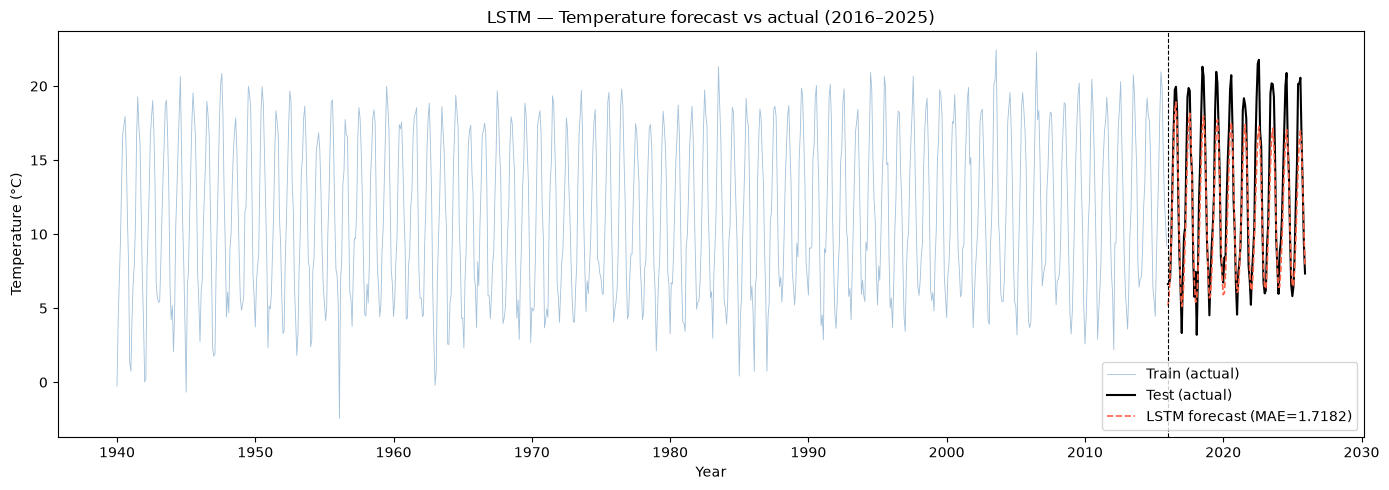

In [93]:
plt.figure(figsize=(14, 5))
plt.plot(train_full.index, train_full.values, color="steelblue", linewidth=0.6, alpha=0.5, label="Train (actual)")
plt.plot(test_full.index, test_full.values,   color="black",     linewidth=1.5, label="Test (actual)")
plt.plot(test_full.index, lstm_forecast,      color="tomato",    linewidth=1.2, linestyle="--", label=f"LSTM forecast (MAE={mae_lstm:.4f})")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("LSTM — Temperature forecast vs actual (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.9b LSTM with CO2 + cyclic month features

In [94]:
# CO2 starts in 1958, so we're limited to 1958-2025
df_lstm2 = pd.concat([df_co2["co2_ppm"], df_temp], axis=1).loc["1958":"2025"].dropna()
df_lstm2.columns = ["co2_ppm", "temp_celsius"]

In [95]:
# sin/cos encoding to tell the model which month it is
df_lstm2["sin_month"] = np.sin(2 * np.pi * df_lstm2.index.month / 12)
df_lstm2["cos_month"] = np.cos(2 * np.pi * df_lstm2.index.month / 12)

In [96]:
train_lstm2 = df_lstm2.loc[:"2015"]
test_lstm2  = df_lstm2.loc["2016":"2025"]

In [97]:
FEATURE_COLS = ["temp_celsius", "co2_ppm", "sin_month", "cos_month"]
N_FEAT = len(FEATURE_COLS)

In [98]:
# fit on train only to avoid leakage
scaler_feat = MinMaxScaler()
train_feat_scaled = scaler_feat.fit_transform(train_lstm2[FEATURE_COLS])

In [99]:
print(f"train : {train_lstm2.index.min().date()} → {train_lstm2.index.max().date()} ({len(train_lstm2)} months)")
print(f"test  : {test_lstm2.index.min().date()} → {test_lstm2.index.max().date()} ({len(test_lstm2)} months)")
print(f"features : {FEATURE_COLS}")

Train : 1958-03-01 ==> 2015-12-01 (694 months)
Test  : 2016-01-01 ==> 2025-12-01 (120 months)
Features : ['temp_celsius', 'co2_ppm', 'sin_month', 'cos_month']


In [100]:
def make_sequences_multi(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])   # (window, n_features)
        y.append(data[i + window, 0])    # target = temp (column 0)
    return np.array(X), np.array(y)

In [101]:
param_grid_lstm2 = {
    "window"  : [24, 36, 48],
    "units"   : [32, 64, 128],
    "dropout" : [0.1, 0.2, 0.3],
}

In [102]:
results_lstm2 = []

In [103]:
for window, units, dropout in product(
    param_grid_lstm2["window"],
    param_grid_lstm2["units"],
    param_grid_lstm2["dropout"]
):
    tf.random.set_seed(42)
    np.random.seed(42)

    X_tr, y_tr = make_sequences_multi(train_feat_scaled, window)

    m = Sequential([
        LSTM(units, input_shape=(window, N_FEAT), return_sequences=True),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    m.fit(X_tr, y_tr, epochs=150, batch_size=16,
          validation_split=0.1, callbacks=[es], verbose=0)

    # temp is predicted step by step, CO2 + month features are known in advance
    cur = train_feat_scaled[-window:].copy()
    preds = []

    for j in range(len(test_lstm2)):
        p = m.predict(cur.reshape(1, window, N_FEAT), verbose=0)[0, 0]
        preds.append(p)

        next_scaled = scaler_feat.transform(
            test_lstm2.iloc[j][FEATURE_COLS].values.reshape(1, -1)
        )[0]
        next_scaled[0] = p  # swap in the predicted temp
        cur = np.vstack([cur[1:], next_scaled])

    # inverse transform — column 0 is temp
    dummy = np.zeros((len(preds), N_FEAT))
    dummy[:, 0] = preds
    fc = scaler_feat.inverse_transform(dummy)[:, 0]

    mae_i = mean_absolute_error(test_full, fc)
    results_lstm2.append({"window": window, "units": units, "dropout": dropout, "MAE": mae_i})
    print(f"w={window}  u={units}  d={dropout}  MAE={mae_i:.4f}")

window=24  units= 32  dropout=0.1  →  MAE=0.8519
window=24  units= 32  dropout=0.2  →  MAE=0.8771
window=24  units= 32  dropout=0.3  →  MAE=0.9940
window=24  units= 64  dropout=0.1  →  MAE=0.9320
window=24  units= 64  dropout=0.2  →  MAE=0.9468
window=24  units= 64  dropout=0.3  →  MAE=0.9385
window=24  units=128  dropout=0.1  →  MAE=0.8599
window=24  units=128  dropout=0.2  →  MAE=0.8386
window=24  units=128  dropout=0.3  →  MAE=1.0023
window=36  units= 32  dropout=0.1  →  MAE=0.9685
window=36  units= 32  dropout=0.2  →  MAE=0.9171
window=36  units= 32  dropout=0.3  →  MAE=0.9351
window=36  units= 64  dropout=0.1  →  MAE=0.9068
window=36  units= 64  dropout=0.2  →  MAE=0.8891
window=36  units= 64  dropout=0.3  →  MAE=0.8539
window=36  units=128  dropout=0.1  →  MAE=0.8766
window=36  units=128  dropout=0.2  →  MAE=0.9094
window=36  units=128  dropout=0.3  →  MAE=0.9493
window=48  units= 32  dropout=0.1  →  MAE=0.9190
window=48  units= 32  dropout=0.2  →  MAE=0.9109
window=48  units= 32

In [104]:
df_results_lstm2 = pd.DataFrame(results_lstm2).sort_values("MAE").reset_index(drop=True)
print("top 5 :")
print(df_results_lstm2.head())


--- Top 5 combinations ---
   window  units  dropout       MAE
0      24    128      0.2  0.838591
1      24     32      0.1  0.851850
2      36     64      0.3  0.853899
3      24    128      0.1  0.859946
4      48     32      0.3  0.869673


In [105]:
best2 = df_results_lstm2.iloc[0]
W2 = int(best2["window"])
U2 = int(best2["units"])
D2 = best2["dropout"]

In [106]:
print(f"best : window={W2}  units={U2}  dropout={D2}")

Best params : window=24, units=128, dropout=0.2


In [107]:
X_tr_best2, y_tr_best2 = make_sequences_multi(train_feat_scaled, W2)

In [108]:
model_lstm2 = Sequential([
    LSTM(U2, input_shape=(W2, N_FEAT), return_sequences=True),
    Dropout(D2),
    LSTM(U2 // 2),
    Dropout(D2),
    Dense(1)
])

In [109]:
model_lstm2.compile(optimizer="adam", loss="mse")

In [110]:
es2 = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
history2 = model_lstm2.fit(
    X_tr_best2, y_tr_best2,
    epochs=150, batch_size=16,
    validation_split=0.1,
    callbacks=[es2], verbose=0
)

In [111]:
cur = train_feat_scaled[-W2:].copy()
preds_final = []
for j in range(len(test_lstm2)):
    p = model_lstm2.predict(cur.reshape(1, W2, N_FEAT), verbose=0)[0, 0]
    preds_final.append(p)
    next_scaled = scaler_feat.transform(
        test_lstm2.iloc[j][FEATURE_COLS].values.reshape(1, -1)
    )[0]
    next_scaled[0] = p
    cur = np.vstack([cur[1:], next_scaled])

In [112]:
dummy2 = np.zeros((len(preds_final), N_FEAT))
dummy2[:, 0] = preds_final
lstm2_forecast = scaler_feat.inverse_transform(dummy2)[:, 0]
lstm2_forecast = pd.Series(lstm2_forecast, index=test_full.index)


In [113]:
mae_lstm2  = mean_absolute_error(test_full, lstm2_forecast)
rmse_lstm2 = np.sqrt(mean_squared_error(test_full, lstm2_forecast))
mape_lstm2 = np.mean(np.abs((test_full - lstm2_forecast) / test_full)) * 100


In [114]:
print(f"LSTM v2  →  MAE={mae_lstm2:.4f}°C  RMSE={rmse_lstm2:.4f}°C  MAPE={mape_lstm2:.2f}%")
print(f"vs LSTM baseline : MAE={mae_lstm:.4f}  RMSE={rmse_lstm:.4f}")


--- LSTM v2 (CO2 + sin/cos) — Test set metrics ---
MAE  : 0.9470 °C  (vs 1.7182 LSTM baseline)
RMSE : 1.1563 °C  (vs 2.1587 LSTM baseline)
MAPE : 9.40 %


In [115]:
print(f"{'Model':<42} {'Train from':>12} {'MAE':>8} {'RMSE':>8}")
print("-" * 74)
print(f"{'SARIMA (baseline)':<42} {'1993':>12} {mae:>7.4f}  {rmse:>7.4f}")
print(f"{'Prophet (CO2, tuned)':<42} {'1993':>12} {best_mae_p:>7.4f}  {rmse_best:>7.4f}")
print(f"{'SARIMA (full history)':<42} {'1940':>12} {mae_sf:>7.4f}  {rmse_sf:>7.4f}")
print(f"{'Prophet (CO2, tuned, extended)':<42} {'1958':>12} {mae_pe:>7.4f}  {rmse_pe:>7.4f}")
print(f"{'LSTM (baseline)':<42} {'1940':>12} {mae_lstm:>7.4f}  {rmse_lstm:>7.4f}")
print(f"{'LSTM v2 (CO2 + sin/cos month)':<42} {'1958':>12} {mae_lstm2:>7.4f}  {rmse_lstm2:>7.4f}")

Model                                        Train from      MAE     RMSE
--------------------------------------------------------------------------
SARIMA (baseline)                                  1993  0.9078   1.1223
Prophet (CO2, tuned)                               1993  0.8445   1.0514
SARIMA (full history)                              1940  0.8967   1.1134
Prophet (CO2, tuned, extended)                     1958  0.8370   1.0582
LSTM (baseline)                                    1940  1.7182   2.1587
LSTM v2 (CO2 + sin/cos month)                      1958  0.9470   1.1563


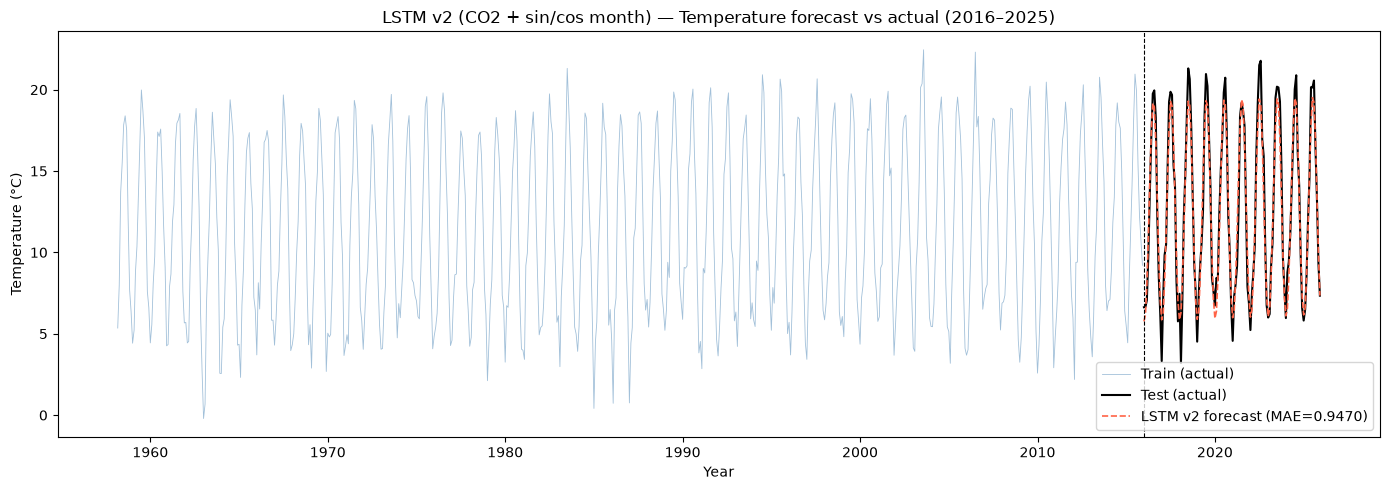

In [116]:
plt.figure(figsize=(14, 5))
plt.plot(train_lstm2.index, train_lstm2["temp_celsius"], color="steelblue", linewidth=0.6, alpha=0.5, label="Train (actual)")
plt.plot(test_full.index,   test_full.values,            color="black",     linewidth=1.5, label="Test (actual)")
plt.plot(test_full.index,   lstm2_forecast,              color="tomato",    linewidth=1.2, linestyle="--", label=f"LSTM v2 forecast (MAE={mae_lstm2:.4f})")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("LSTM v2 (CO2 + sin/cos month) — Temperature forecast vs actual (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. CO2 Modelling

CO2 has two strong signals in the EDA:
- Upward trend (315 ppm in 1958 → 420+ ppm in 2025)
- Annual cycle (~±3 ppm) driven by Northern Hemisphere vegetation

### 4.1 Train / Test split

In [117]:
co2_series = df_co2["co2_ppm"]

In [118]:
train_co2 = co2_series.loc[:"2015"]
test_co2  = co2_series.loc["2016":"2025"]

In [119]:
print(f"train : {train_co2.index.min().date()} → {train_co2.index.max().date()} ({len(train_co2)} months)")
print(f"test  : {test_co2.index.min().date()} → {test_co2.index.max().date()} ({len(test_co2)} months)")

Train : 1958-03-01 ==> 2015-12-01 (694 months)
Test  : 2016-01-01 ==> 2025-12-01 (120 months)


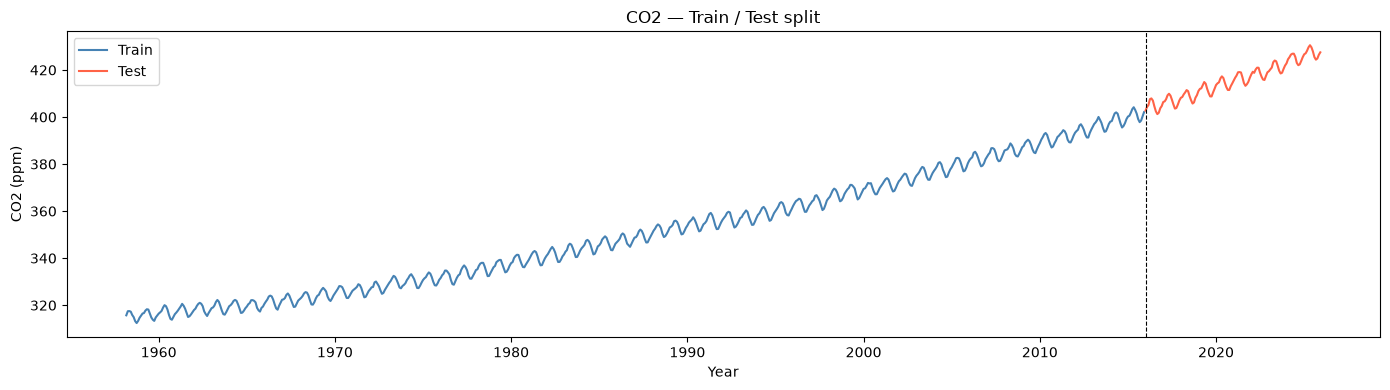

In [120]:
plt.figure(figsize=(14, 4))
plt.plot(train_co2.index, train_co2.values, label="Train", color="steelblue")
plt.plot(test_co2.index,  test_co2.values,  label="Test",  color="tomato")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("CO2 — Train / Test split")
plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 SARIMA — CO2

In [121]:
best_aic_co2   = np.inf
best_order_co2 = None
best_fit_co2   = None

In [122]:
for p in [0, 1, 2]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    mdl = SARIMAX(train_co2,
                                  order=(p, 1, q),
                                  seasonal_order=(P, 1, Q, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
                    res = mdl.fit(disp=False)
                    if res.aic < best_aic_co2:
                        best_aic_co2   = res.aic
                        best_order_co2 = (p, 1, q, P, 1, Q)
                        best_fit_co2   = res
                except Exception:
                    continue

In [123]:
p, d, q, P, D, Q = best_order_co2
print(f"best order : SARIMA({p},{d},{q})({P},{D},{Q})[12]  AIC={best_aic_co2:.2f}")

Best order : SARIMA(1,1,1)(1,1,1)[12]
AIC        : 314.38


In [124]:
sarima_co2_forecast = best_fit_co2.forecast(steps=len(test_co2))
sarima_co2_forecast.index = test_co2.index


In [125]:
mae_co2_sarima  = mean_absolute_error(test_co2, sarima_co2_forecast)
rmse_co2_sarima = np.sqrt(mean_squared_error(test_co2, sarima_co2_forecast))
print(f"SARIMA CO2  →  MAE={mae_co2_sarima:.4f} ppm  RMSE={rmse_co2_sarima:.4f} ppm")

SARIMA CO2 — MAE : 2.0259 ppm  |  RMSE : 2.3577 ppm


### 4.3 Prophet — CO2 (grid search)

In [126]:
train_co2_df = train_co2.reset_index().rename(columns={"date": "ds", "co2_ppm": "y"})
test_co2_df  = test_co2.reset_index().rename(columns={"date": "ds", "co2_ppm": "y"})


In [127]:
param_grid_co2 = {
    "changepoint_prior_scale" : [0.01, 0.1, 0.3, 0.5],
    "seasonality_prior_scale" : [1.0, 10.0],
    "seasonality_mode"        : ["additive", "multiplicative"],
}

In [128]:
keys_co2   = list(param_grid_co2.keys())
values_co2 = list(param_grid_co2.values())


In [129]:
best_mae_co2_p   = np.inf
best_params_co2  = None
best_fc_co2      = None

In [130]:
for combo in product(*values_co2):
    params = dict(zip(keys_co2, combo))
    try:
        m = Prophet(**params, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.fit(train_co2_df)
        fc = m.predict(test_co2_df[["ds"]])
        mae_i = mean_absolute_error(test_co2, fc["yhat"].values)
        if mae_i < best_mae_co2_p:
            best_mae_co2_p  = mae_i
            best_params_co2 = params
            best_fc_co2     = fc
    except Exception:
        continue

01:16:17 - cmdstanpy - INFO - Chain [1] start processing
01:16:17 - cmdstanpy - INFO - Chain [1] done processing
01:16:17 - cmdstanpy - INFO - Chain [1] start processing
01:16:17 - cmdstanpy - INFO - Chain [1] done processing
01:16:17 - cmdstanpy - INFO - Chain [1] start processing
01:16:18 - cmdstanpy - INFO - Chain [1] done processing
01:16:18 - cmdstanpy - INFO - Chain [1] start processing
01:16:18 - cmdstanpy - INFO - Chain [1] done processing
01:16:18 - cmdstanpy - INFO - Chain [1] start processing
01:16:18 - cmdstanpy - INFO - Chain [1] done processing
01:16:18 - cmdstanpy - INFO - Chain [1] start processing
01:16:18 - cmdstanpy - INFO - Chain [1] done processing
01:16:18 - cmdstanpy - INFO - Chain [1] start processing
01:16:19 - cmdstanpy - INFO - Chain [1] done processing
01:16:19 - cmdstanpy - INFO - Chain [1] start processing
01:16:19 - cmdstanpy - INFO - Chain [1] done processing
01:16:19 - cmdstanpy - INFO - Chain [1] start processing
01:16:19 - cmdstanpy - INFO - Chain [1]

In [131]:
print("best params (CO2) :")
for k, v in best_params_co2.items():
    print(f"  {k} = {v}")
print(f"best MAE : {best_mae_co2_p:.4f} ppm")

Best hyperparameters (CO2) :
  changepoint_prior_scale : 0.01
  seasonality_prior_scale : 10.0
  seasonality_mode : multiplicative

Best MAE : 3.2304 ppm


### 4.4 Comparison — SARIMA vs Prophet on CO2

In [132]:
prophet_co2_forecast = pd.Series(best_fc_co2["yhat"].values, index=test_co2.index)
rmse_co2_prophet = np.sqrt(mean_squared_error(test_co2, prophet_co2_forecast))

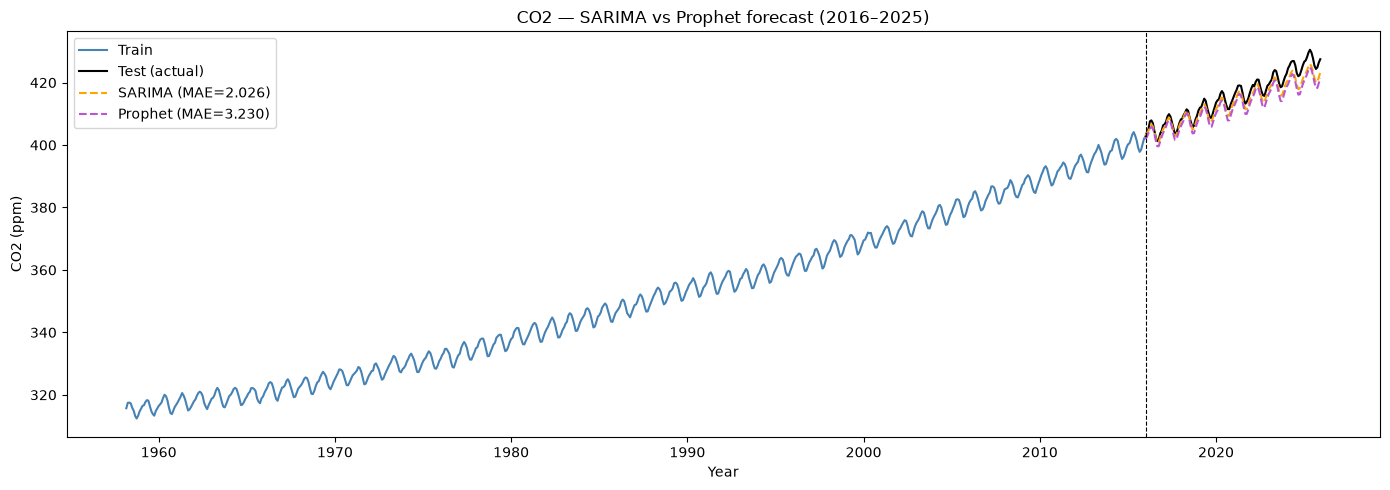

In [133]:
plt.figure(figsize=(14, 5))
plt.plot(train_co2.index, train_co2.values,        label="Train",            color="steelblue")
plt.plot(test_co2.index,  test_co2.values,         label="Test (actual)",    color="black",        linewidth=1.5)
plt.plot(test_co2.index,  sarima_co2_forecast,     label=f"SARIMA (MAE={mae_co2_sarima:.3f})",   color="orange",       linestyle="--")
plt.plot(test_co2.index,  prophet_co2_forecast,    label=f"Prophet (MAE={best_mae_co2_p:.3f})",  color="mediumorchid", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("CO2 — SARIMA vs Prophet forecast (2016–2025)")
plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.tight_layout()
plt.show()

In [134]:
print(f"\n{'Model':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'SARIMA':<20} {mae_co2_sarima:>9.4f}  {rmse_co2_sarima:>9.4f}")
print(f"{'Prophet (tuned)':<20} {best_mae_co2_p:>9.4f}  {rmse_co2_prophet:>9.4f}")


Model                       MAE       RMSE
------------------------------------------
SARIMA                  2.0259     2.3577
Prophet (tuned)         3.2304     3.5217


## 5. Sea Level Modelling

The sea level series (NOAA/CNES satellite altimetry) shows:
- Strong and steady upward trend (~100 mm from 1993 to 2025)
- Very weak annual seasonality compared to CO2 or temperature

### 5.1 Train / Test split

In [135]:
sea_series = df_sl["sea_level_mm"]
train_sl = sea_series.loc[:"2015"]
test_sl  = sea_series.loc["2016":"2025"]

In [136]:
print(f"train : {train_sl.index.min().date()} → {train_sl.index.max().date()} ({len(train_sl)} months)")
print(f"test  : {test_sl.index.min().date()} → {test_sl.index.max().date()} ({len(test_sl)} months)")

Train : 1992-12-01 ==> 2015-12-01 (277 months)
Test  : 2016-01-01 ==> 2025-12-01 (120 months)


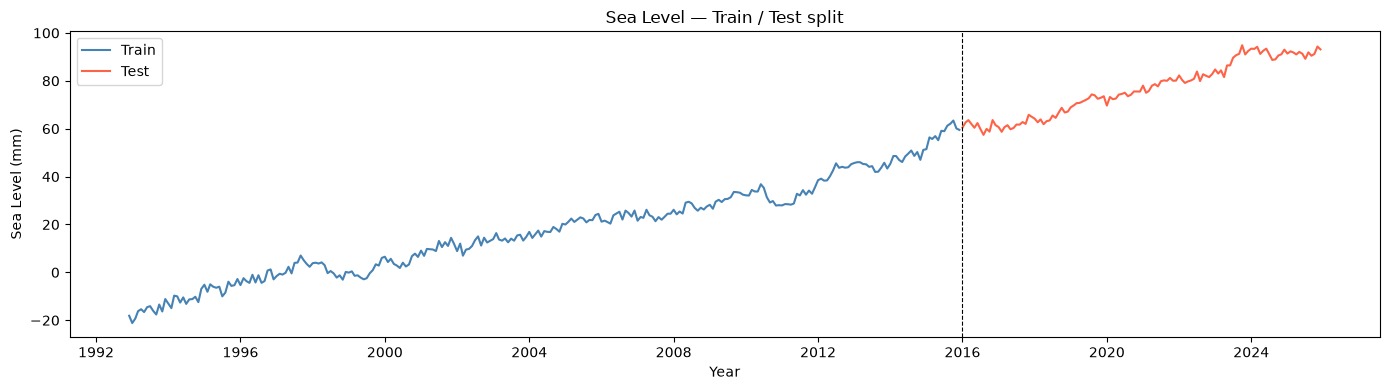

In [137]:
plt.figure(figsize=(14, 4))
plt.plot(train_sl.index, train_sl.values, label="Train", color="steelblue")
plt.plot(test_sl.index,  test_sl.values,  label="Test",  color="tomato")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("Sea Level — Train / Test split")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 SARIMA — Sea Level

In [138]:
best_aic_sl   = np.inf
best_order_sl = None
best_fit_sl   = None

In [139]:
for p in [0, 1, 2]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    mdl = SARIMAX(train_sl,
                                  order=(p, 1, q),
                                  seasonal_order=(P, 1, Q, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
                    res = mdl.fit(disp=False)
                    if res.aic < best_aic_sl:
                        best_aic_sl   = res.aic
                        best_order_sl = (p, 1, q, P, 1, Q)
                        best_fit_sl   = res
                except Exception:
                    continue

In [140]:
p, d, q, P, D, Q = best_order_sl
print(f"best order : SARIMA({p},{d},{q})({P},{D},{Q})[12]  AIC={best_aic_sl:.2f}")

Best order : SARIMA(0,1,1)(0,1,1)[12]
AIC        : 1064.73


In [141]:
sarima_sl_forecast = best_fit_sl.forecast(steps=len(test_sl))
sarima_sl_forecast.index = test_sl.index

In [142]:
mae_sl_sarima  = mean_absolute_error(test_sl, sarima_sl_forecast)
rmse_sl_sarima = np.sqrt(mean_squared_error(test_sl, sarima_sl_forecast))
print(f"SARIMA sea level  →  MAE={mae_sl_sarima:.4f} mm  RMSE={rmse_sl_sarima:.4f} mm")

SARIMA Sea Level — MAE : 3.9789 mm  |  RMSE : 4.4621 mm


### 5.3 Prophet — Sea Level (grid search)

In [143]:
train_sl_df = train_sl.reset_index().rename(columns={"date": "ds", "sea_level_mm": "y"})
test_sl_df  = test_sl.reset_index().rename(columns={"date": "ds", "sea_level_mm": "y"})

In [144]:
param_grid_sl = {
    "changepoint_prior_scale" : [0.01, 0.1, 0.3, 0.5],
    "seasonality_prior_scale" : [1.0, 10.0],
    "seasonality_mode"        : ["additive", "multiplicative"],
}

In [145]:
keys_sl   = list(param_grid_sl.keys())
values_sl = list(param_grid_sl.values())

In [146]:
best_mae_sl_p   = np.inf
best_params_sl  = None
best_fc_sl      = None

In [147]:
for combo in product(*values_sl):
    params = dict(zip(keys_sl, combo))
    try:
        m = Prophet(**params, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.fit(train_sl_df)
        fc = m.predict(test_sl_df[["ds"]])
        mae_i = mean_absolute_error(test_sl, fc["yhat"].values)
        if mae_i < best_mae_sl_p:
            best_mae_sl_p  = mae_i
            best_params_sl = params
            best_fc_sl     = fc
    except Exception:
        continue

01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:25 - cmdstanpy - INFO - Chain [1] done processing
01:16:25 - cmdstanpy - INFO - Chain [1] start processing
01:16:26 - cmdstanpy - INFO - Chain [1] done processing
01:16:26 - cmdstanpy - INFO - Chain [1] start processing
01:16:26 - cmdstanpy - INFO - Chain [1]

In [148]:
print("best params (sea level) :")
for k, v in best_params_sl.items():
    print(f"  {k} = {v}")
print(f"best MAE : {best_mae_sl_p:.4f} mm")

Best hyperparameters (Sea Level) :
  changepoint_prior_scale : 0.01
  seasonality_prior_scale : 10.0
  seasonality_mode : additive

Best MAE : 5.7825 mm


### 5.4 Comparison — SARIMA vs Prophet on Sea Level

In [149]:
prophet_sl_forecast = pd.Series(best_fc_sl["yhat"].values, index=test_sl.index)
rmse_sl_prophet = np.sqrt(mean_squared_error(test_sl, prophet_sl_forecast))

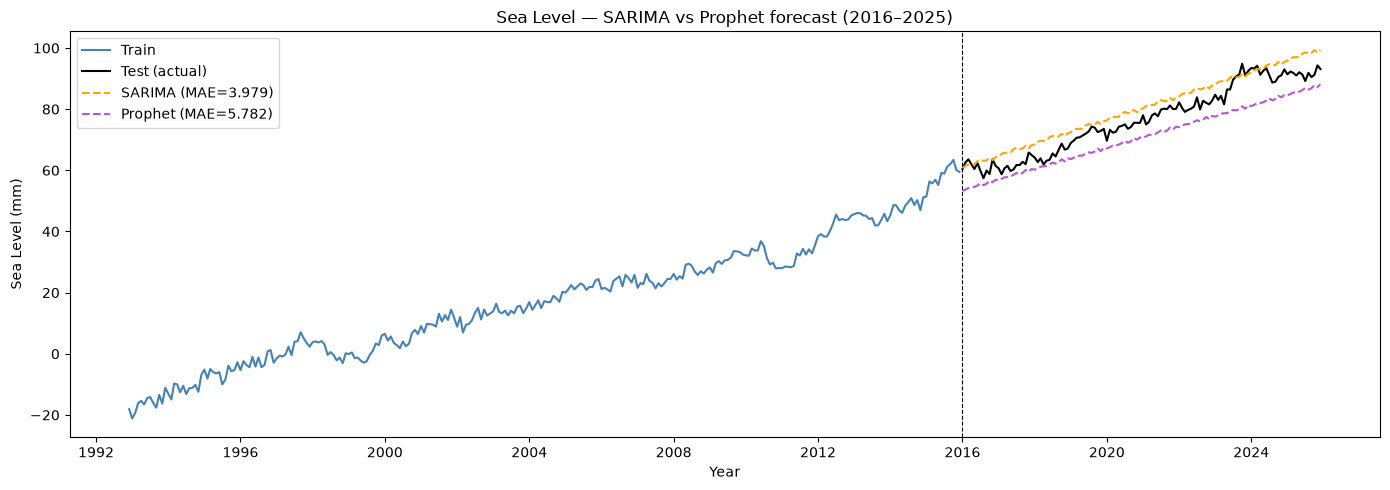

In [150]:
plt.figure(figsize=(14, 5))
plt.plot(train_sl.index, train_sl.values,       label="Train",                                        color="steelblue")
plt.plot(test_sl.index,  test_sl.values,        label="Test (actual)",                                color="black",        linewidth=1.5)
plt.plot(test_sl.index,  sarima_sl_forecast,    label=f"SARIMA (MAE={mae_sl_sarima:.3f})",            color="orange",       linestyle="--")
plt.plot(test_sl.index,  prophet_sl_forecast,   label=f"Prophet (MAE={best_mae_sl_p:.3f})",           color="mediumorchid", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("Sea Level — SARIMA vs Prophet forecast (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.legend()
plt.tight_layout()
plt.show()

In [151]:
print(f"\n{'Model':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'SARIMA':<20} {mae_sl_sarima:>9.4f}  {rmse_sl_sarima:>9.4f}")
print(f"{'Prophet (tuned)':<20} {best_mae_sl_p:>9.4f}  {rmse_sl_prophet:>9.4f}")


Model                       MAE       RMSE
------------------------------------------
SARIMA                  3.9789     4.4621
Prophet (tuned)         5.7825     6.3350


### 5.5 SARIMAX — Sea Level with CO2 as exogenous variable

CO2 and sea level have a 0.99 correlation. Adding CO2 as an exogenous variable should help the model follow the long-term trend.

In [152]:
co2_train_exog = df_co2["co2_ppm"].reindex(train_sl.index)
co2_test_exog  = df_co2["co2_ppm"].reindex(test_sl.index)
print(f"NaN in CO2 train: {co2_train_exog.isna().sum()}  test: {co2_test_exog.isna().sum()}")

CO2 train NaN : 0
CO2 test  NaN : 0


In [153]:
sarimax_sl_mdl = SARIMAX(train_sl,
                         exog=co2_train_exog,
                         order=(0, 1, 1),
                         seasonal_order=(0, 1, 1, 12),
                         enforce_stationarity=False,
                         enforce_invertibility=False)
sarimax_sl_fit = sarimax_sl_mdl.fit(disp=False)

In [154]:
sarimax_sl_forecast = sarimax_sl_fit.forecast(steps=len(test_sl), exog=co2_test_exog)
sarimax_sl_forecast.index = test_sl.index

mae_sl_sarimax  = mean_absolute_error(test_sl, sarimax_sl_forecast)
rmse_sl_sarimax = np.sqrt(mean_squared_error(test_sl, sarimax_sl_forecast))
print(f"SARIMAX (+CO2)  →  MAE={mae_sl_sarimax:.4f} mm  RMSE={rmse_sl_sarimax:.4f} mm")
print(f"improvement vs SARIMA : MAE {mae_sl_sarima - mae_sl_sarimax:+.4f}  RMSE {rmse_sl_sarima - rmse_sl_sarimax:+.4f}")

SARIMAX (+ CO2) — MAE : 3.4446 mm  |  RMSE : 3.8869 mm
Improvement vs SARIMA — MAE : +0.5343 mm  |  RMSE : +0.5752 mm


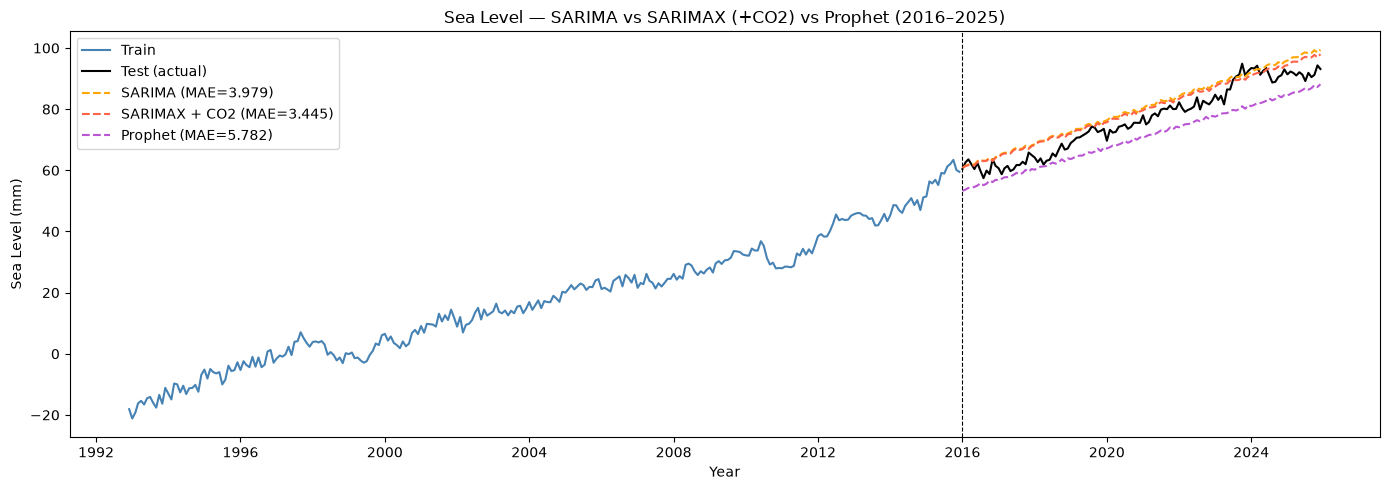

In [155]:
plt.figure(figsize=(14, 5))
plt.plot(train_sl.index, train_sl.values,        label="Train",                                          color="steelblue")
plt.plot(test_sl.index,  test_sl.values,         label="Test (actual)",                                  color="black",        linewidth=1.5)
plt.plot(test_sl.index,  sarima_sl_forecast,     label=f"SARIMA (MAE={mae_sl_sarima:.3f})",              color="orange",       linestyle="--")
plt.plot(test_sl.index,  sarimax_sl_forecast,    label=f"SARIMAX + CO2 (MAE={mae_sl_sarimax:.3f})",      color="tomato",       linestyle="--")
plt.plot(test_sl.index,  prophet_sl_forecast,    label=f"Prophet (MAE={best_mae_sl_p:.3f})",             color="mediumorchid", linestyle="--")
plt.axvline(pd.Timestamp("2016-01-01"), color="black", linestyle="--", linewidth=0.8)
plt.title("Sea Level — SARIMA vs SARIMAX (+CO2) vs Prophet (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.legend()
plt.tight_layout()
plt.show()

In [156]:
print(f"\n{'Model':<25} {'MAE':>10} {'RMSE':>10}")
print("-" * 47)
print(f"{'SARIMA':<25} {mae_sl_sarima:>9.4f}  {rmse_sl_sarima:>9.4f}")
print(f"{'SARIMAX (+ CO2)':<25} {mae_sl_sarimax:>9.4f}  {rmse_sl_sarimax:>9.4f}")
print(f"{'Prophet (tuned)':<25} {best_mae_sl_p:>9.4f}  {rmse_sl_prophet:>9.4f}")


Model                            MAE       RMSE
-----------------------------------------------
SARIMA                       3.9789     4.4621
SARIMAX (+ CO2)              3.4446     3.8869
Prophet (tuned)              5.7825     6.3350


## 3.10 Re-training — new split (1958–2019 / 2020–2025)

We extend the training window by 4 years (up to end of 2019) and test on 2020-2025.
Goal: see if more training data improves results on the more recent period.

In [157]:
# rebuild dataset with extended training window
df_new = pd.concat([df_co2["co2_ppm"], df_temp], axis=1).loc["1958":"2025"].dropna()
df_new.columns = ["co2_ppm", "temp_celsius"]
df_new["sin_month"] = np.sin(2 * np.pi * df_new.index.month / 12)
df_new["cos_month"] = np.cos(2 * np.pi * df_new.index.month / 12)

train_new = df_new.loc[:"2019"]
test_new  = df_new.loc["2020":"2025"]

print(f"train : {train_new.index.min().date()} → {train_new.index.max().date()} ({len(train_new)} months)")
print(f"test  : {test_new.index.min().date()} → {test_new.index.max().date()} ({len(test_new)} months)")

Train : 1958-03-01 → 2019-12-01 (742 months)
Test  : 2020-01-01 → 2025-12-01 (72 months)


### 3.10.1 Prophet + CO2 (grid search, new split)

In [158]:
train_new_df = train_new.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})
test_new_df  = test_new.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})

param_grid_new = {
    "changepoint_prior_scale" : [0.01, 0.1, 0.3, 0.5],
    "seasonality_prior_scale" : [1.0, 10.0],
    "seasonality_mode"        : ["additive", "multiplicative"],
}
keys_new   = list(param_grid_new.keys())
values_new = list(param_grid_new.values())

In [159]:
best_mae_new_p    = np.inf
best_params_new_p = None
best_fc_new_p     = None

for combo in product(*values_new):
    params = dict(zip(keys_new, combo))
    try:
        m = Prophet(**params, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.add_regressor("co2_ppm")
        m.fit(train_new_df)
        fc = m.predict(test_new_df[["ds", "co2_ppm"]])
        mae_i = mean_absolute_error(test_new["temp_celsius"], fc["yhat"].values)
        if mae_i < best_mae_new_p:
            best_mae_new_p    = mae_i
            best_params_new_p = params
            best_fc_new_p     = fc
    except Exception:
        pass

01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing
01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:13 - cmdstanpy - INFO - Chain [1] done processing
01:34:13 - cmdstanpy - INFO - Chain [1] start processing
01:34:13 - cmdstanpy - INFO - Chain [1]

In [160]:
print("best params (new split) :")
for k, v in best_params_new_p.items():
    print(f"  {k} = {v}")
print(f"best MAE : {best_mae_new_p:.4f}°C")

Best hyperparameters (Prophet, new split) :
  changepoint_prior_scale : 0.01
  seasonality_prior_scale : 1.0
  seasonality_mode : additive

Best MAE : 0.7755 °C


In [161]:
prophet_new_forecast = pd.Series(best_fc_new_p["yhat"].values, index=test_new.index)
mae_new_p  = mean_absolute_error(test_new["temp_celsius"], prophet_new_forecast)
rmse_new_p = np.sqrt(mean_squared_error(test_new["temp_celsius"], prophet_new_forecast))
print(f"Prophet (CO2, new split)  MAE : {mae_new_p:.4f} °C  |  RMSE : {rmse_new_p:.4f} °C")

Prophet (CO2, new split)  MAE : 0.7755 °C  |  RMSE : 1.0016 °C


### 3.10.2 LSTM v2 (CO2 + sin/cos, grid search, new split)

In [162]:
FEATURE_COLS_N = ["temp_celsius", "co2_ppm", "sin_month", "cos_month"]
N_FEAT_N = len(FEATURE_COLS_N)

scaler_new = MinMaxScaler()
train_feat_scaled_new = scaler_new.fit_transform(train_new[FEATURE_COLS_N])

print(f"train shape : {train_feat_scaled_new.shape}")

Train scaled shape : (742, 4)
Features : ['temp_celsius', 'co2_ppm', 'sin_month', 'cos_month']


In [163]:
param_grid_lstm_new = {
    "window"  : [24, 36, 48],
    "units"   : [32, 64, 128],
    "dropout" : [0.1, 0.2, 0.3],
}

results_lstm_new = []

for window, units, dropout in product(
    param_grid_lstm_new["window"],
    param_grid_lstm_new["units"],
    param_grid_lstm_new["dropout"]
):
    tf.random.set_seed(42)
    np.random.seed(42)

    X_tr, y_tr = make_sequences_multi(train_feat_scaled_new, window)

    m = Sequential([
        LSTM(units, input_shape=(window, N_FEAT_N), return_sequences=True),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    m.fit(X_tr, y_tr, epochs=100, batch_size=16,
          validation_split=0.1, callbacks=[es], verbose=0)

    cur = train_feat_scaled_new[-window:].copy()
    preds = []
    for j in range(len(test_new)):
        p = m.predict(cur.reshape(1, window, N_FEAT_N), verbose=0)[0, 0]
        preds.append(p)
        next_row = scaler_new.transform(
            test_new.iloc[j][FEATURE_COLS_N].values.reshape(1, -1)
        )[0]
        next_row[0] = p
        cur = np.vstack([cur[1:], next_row])

    dummy = np.zeros((len(preds), N_FEAT_N))
    dummy[:, 0] = preds
    fc_inv = scaler_new.inverse_transform(dummy)[:, 0]
    mae_i = mean_absolute_error(test_new["temp_celsius"], fc_inv)
    results_lstm_new.append({"window": window, "units": units, "dropout": dropout, "MAE": mae_i})
    print(f"w={window}  u={units}  d={dropout}  MAE={mae_i:.4f}")

window=24  units= 32  dropout=0.1  →  MAE=0.8356
window=24  units= 32  dropout=0.2  →  MAE=0.9713
window=24  units= 32  dropout=0.3  →  MAE=0.8349
window=24  units= 64  dropout=0.1  →  MAE=0.8155
window=24  units= 64  dropout=0.2  →  MAE=0.8898
window=24  units= 64  dropout=0.3  →  MAE=0.7990
window=24  units=128  dropout=0.1  →  MAE=0.7824
window=24  units=128  dropout=0.2  →  MAE=0.7911
window=24  units=128  dropout=0.3  →  MAE=0.8515
window=36  units= 32  dropout=0.1  →  MAE=0.8369
window=36  units= 32  dropout=0.2  →  MAE=0.8219
window=36  units= 32  dropout=0.3  →  MAE=0.8158
window=36  units= 64  dropout=0.1  →  MAE=0.8473
window=36  units= 64  dropout=0.2  →  MAE=0.7925
window=36  units= 64  dropout=0.3  →  MAE=0.8602
window=36  units=128  dropout=0.1  →  MAE=0.8677
window=36  units=128  dropout=0.2  →  MAE=0.8482
window=36  units=128  dropout=0.3  →  MAE=0.8326
window=48  units= 32  dropout=0.1  →  MAE=0.8000
window=48  units= 32  dropout=0.2  →  MAE=0.8118
window=48  units= 32

In [164]:
df_results_lstm_new = pd.DataFrame(results_lstm_new).sort_values("MAE").reset_index(drop=True)
print("top 5 :")
print(df_results_lstm_new.head())


--- Top 5 combinations ---
   window  units  dropout       MAE
0      24    128      0.1  0.782426
1      24    128      0.2  0.791102
2      36     64      0.2  0.792502
3      24     64      0.3  0.799048
4      48     32      0.1  0.800024


In [165]:
best_lstm_new = df_results_lstm_new.iloc[0]
W_N = int(best_lstm_new["window"])
U_N = int(best_lstm_new["units"])
D_N = best_lstm_new["dropout"]
print(f"best : window={W_N}  units={U_N}  dropout={D_N}")

tf.random.set_seed(42)
np.random.seed(42)

X_tr_n, y_tr_n = make_sequences_multi(train_feat_scaled_new, W_N)

model_lstm_new = Sequential([
    LSTM(U_N, input_shape=(W_N, N_FEAT_N), return_sequences=True),
    Dropout(D_N),
    LSTM(U_N // 2),
    Dropout(D_N),
    Dense(1)
])
model_lstm_new.compile(optimizer="adam", loss="mse")
es_n = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
history_n = model_lstm_new.fit(
    X_tr_n, y_tr_n,
    epochs=150, batch_size=16,
    validation_split=0.1,
    callbacks=[es_n], verbose=0
)
print(f"stopped at epoch {len(history_n.history['loss'])}")

Best params : window=24, units=128, dropout=0.1
Stopped at epoch 32


In [166]:
cur = train_feat_scaled_new[-W_N:].copy()
preds_new = []
for j in range(len(test_new)):
    p = model_lstm_new.predict(cur.reshape(1, W_N, N_FEAT_N), verbose=0)[0, 0]
    preds_new.append(p)
    next_row = scaler_new.transform(
        test_new.iloc[j][FEATURE_COLS_N].values.reshape(1, -1)
    )[0]
    next_row[0] = p
    cur = np.vstack([cur[1:], next_row])

dummy_n = np.zeros((len(preds_new), N_FEAT_N))
dummy_n[:, 0] = preds_new
lstm_new_forecast = scaler_new.inverse_transform(dummy_n)[:, 0]
lstm_new_forecast = pd.Series(lstm_new_forecast, index=test_new.index)

In [167]:
mae_lstm_new  = mean_absolute_error(test_new["temp_celsius"], lstm_new_forecast)
rmse_lstm_new = np.sqrt(mean_squared_error(test_new["temp_celsius"], lstm_new_forecast))
print(f"LSTM v2 (new split)  MAE : {mae_lstm_new:.4f} °C  |  RMSE : {rmse_lstm_new:.4f} °C")

LSTM v2 (new split)  MAE : 0.7774 °C  |  RMSE : 1.0021 °C


### 3.10.3 Comparison — old split (train→2015) vs new split (train→2019)

In [168]:
print(f"\n{'Model':<38} {'Train until':>12} {'Test period':>12} {'MAE':>8} {'RMSE':>8}")
print("-" * 80)
print(f"{'Prophet + CO2 (tuned)':<38} {'2015':>12} {'2016–2025':>12} {mae_pe:>7.4f}  {rmse_pe:>7.4f}")
print(f"{'Prophet + CO2 (new split)':<38} {'2019':>12} {'2020–2025':>12} {mae_new_p:>7.4f}  {rmse_new_p:>7.4f}")
print("-" * 80)
print(f"{'LSTM v2 (CO2 + sin/cos)':<38} {'2015':>12} {'2016–2025':>12} {mae_lstm2:>7.4f}  {rmse_lstm2:>7.4f}")
print(f"{'LSTM v2 (new split)':<38} {'2019':>12} {'2020–2025':>12} {mae_lstm_new:>7.4f}  {rmse_lstm_new:>7.4f}")


Model                                   Train until  Test period      MAE     RMSE
--------------------------------------------------------------------------------
Prophet + CO2 (tuned)                          2015    2016–2025  0.8370   1.0582
Prophet + CO2 (new split)                      2019    2020–2025  0.7755   1.0016
--------------------------------------------------------------------------------
LSTM v2 (CO2 + sin/cos)                        2015    2016–2025  0.9470   1.1563
LSTM v2 (new split)                            2019    2020–2025  0.7774   1.0021


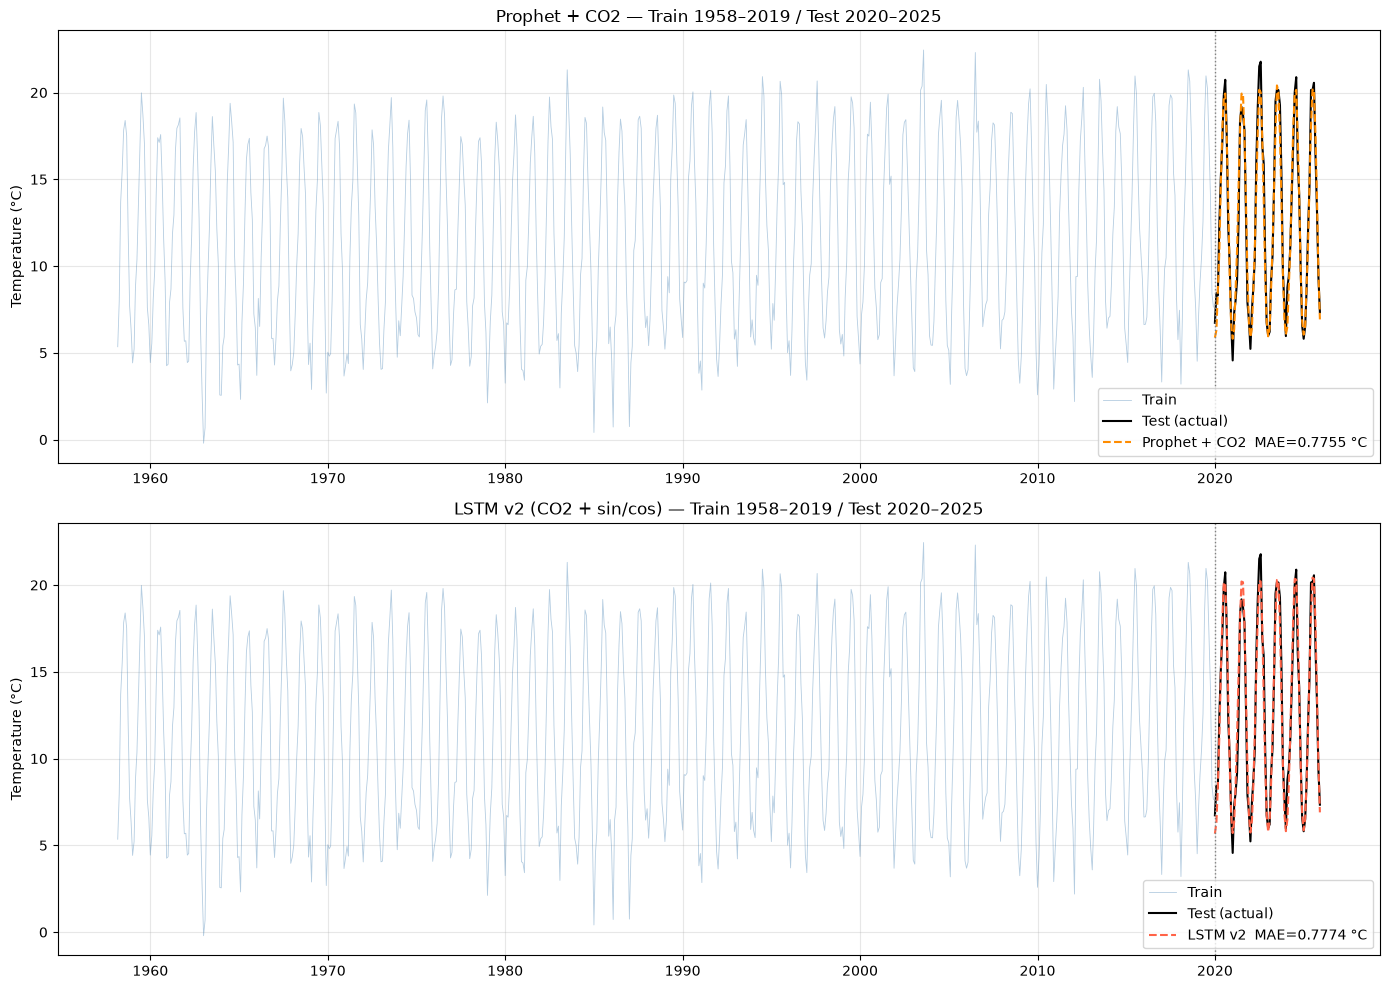

In [169]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(train_new.index, train_new["temp_celsius"],
        color="steelblue", linewidth=0.6, alpha=0.4, label="Train")
ax.plot(test_new.index, test_new["temp_celsius"],
        color="black", linewidth=1.5, label="Test (actual)")
ax.plot(test_new.index, prophet_new_forecast,
        color="darkorange", linewidth=1.5, linestyle="--",
        label=f"Prophet + CO2  MAE={mae_new_p:.4f} °C")
ax.axvline(pd.Timestamp("2020-01-01"), color="gray", linestyle=":", linewidth=1)
ax.set_title("Prophet + CO2 — Train 1958–2019 / Test 2020–2025")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(train_new.index, train_new["temp_celsius"],
         color="steelblue", linewidth=0.6, alpha=0.4, label="Train")
ax2.plot(test_new.index, test_new["temp_celsius"],
         color="black", linewidth=1.5, label="Test (actual)")
ax2.plot(test_new.index, lstm_new_forecast,
         color="tomato", linewidth=1.5, linestyle="--",
         label=f"LSTM v2  MAE={mae_lstm_new:.4f} °C")
ax2.axvline(pd.Timestamp("2020-01-01"), color="gray", linestyle=":", linewidth=1)
ax2.set_title("LSTM v2 (CO2 + sin/cos) — Train 1958–2019 / Test 2020–2025")
ax2.set_ylabel("Temperature (°C)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Chained Pipeline — Future Projections 2026–2035

**Pipeline architecture:**

```
SARIMA(1,1,1)(1,1,1)[12]  →  CO2 forecast 2026–2035
                                      │
                          ┌───────────┴───────────┐
                          ▼                       ▼
              Prophet + CO2 regressor   SARIMAX + CO2 exog
              (Temperature 2026–2035)   (Sea Level 2026–2035)
```

All 3 models are retrained on the full available data (up to 2025) before projecting.

### 6.1 Stage 1 — SARIMA CO2 (1958–2025) → forecast 2026–2035

In [170]:
# retrain on the full CO2 history before projecting
co2_full = df_co2["co2_ppm"].loc["1958":"2025"].dropna()

sarima_co2_pipe = SARIMAX(co2_full,
                          order=(1, 1, 1),
                          seasonal_order=(1, 1, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
sarima_co2_pipe_fit = sarima_co2_pipe.fit(disp=False)
print(f"CO2 SARIMA refit  AIC={sarima_co2_pipe_fit.aic:.2f}  ({co2_full.index.min().date()} → {co2_full.index.max().date()})")

SARIMA CO2 refit — AIC : 419.03
Training period : 1958-03-01 → 2025-12-01 (814 months)


In [171]:
# 10 years = 120 months of monthly projections
future_index = pd.date_range(start="2026-01-01", periods=120, freq="MS")

co2_fc_result  = sarima_co2_pipe_fit.get_forecast(steps=120)
co2_future     = co2_fc_result.predicted_mean
co2_future.index = future_index
co2_ci         = co2_fc_result.conf_int()
co2_ci.index   = future_index

print(f"2025 avg : {co2_full.loc['2025'].mean():.1f} ppm")
print(f"2030 avg : {co2_future.loc['2030'].mean():.1f} ppm")
print(f"2035 avg : {co2_future.loc['2035'].mean():.1f} ppm")

CO2 projected in 2030 : 439.8 ppm
CO2 projected in 2035 : 452.3 ppm
CO2 today (2025 avg)  : 427.3 ppm


### 6.2 Stage 2a — Prophet Temperature (1958–2025, + predicted CO2)

In [172]:
# use full history for final model
df_pipe_temp = pd.concat([df_co2["co2_ppm"], df_temp], axis=1).loc["1958":"2025"].dropna()
df_pipe_temp.columns = ["co2_ppm", "temp_celsius"]

pipe_train_df = df_pipe_temp.reset_index().rename(columns={"date": "ds", "temp_celsius": "y"})

prophet_pipe = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=1.0,
    seasonality_mode="additive",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_pipe.add_regressor("co2_ppm")
prophet_pipe.fit(pipe_train_df)
print(f"Prophet retrained on {len(pipe_train_df)} months")

01:50:50 - cmdstanpy - INFO - Chain [1] start processing
01:50:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet retrained on 814 months (1958–2025)


In [173]:
# chain: predicted CO2 → temperature forecast
future_temp_df = pd.DataFrame({
    "ds"      : future_index,
    "co2_ppm" : co2_future.values
})

temp_fc   = prophet_pipe.predict(future_temp_df)
temp_future       = pd.Series(temp_fc["yhat"].values,       index=future_index)
temp_future_lower = pd.Series(temp_fc["yhat_lower"].values, index=future_index)
temp_future_upper = pd.Series(temp_fc["yhat_upper"].values, index=future_index)

print(f"recent (2020-2025) : {df_temp.loc['2020':'2025'].mean():.2f}°C")
print(f"2030 avg : {temp_future.loc['2030'].mean():.2f}°C")
print(f"2035 avg : {temp_future.loc['2035'].mean():.2f}°C")

Temp projected in 2030 : 13.27 °C (avg)
Temp projected in 2035 : 13.57 °C (avg)
Temp recent (2020–2025): 12.85 °C (avg)


### 6.3 Stage 2b — SARIMAX Sea Level (1992–2025, + predicted CO2)

In [174]:
# retrain with all available data
sl_full       = df_sl["sea_level_mm"].loc["1992":"2025"].dropna()
co2_sl_exog   = df_co2["co2_ppm"].reindex(sl_full.index)

sarimax_sl_pipe = SARIMAX(sl_full,
                          exog=co2_sl_exog,
                          order=(0, 1, 1),
                          seasonal_order=(0, 1, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
sarimax_sl_pipe_fit = sarimax_sl_pipe.fit(disp=False)
print(f"SARIMAX sea level refit  AIC={sarimax_sl_pipe_fit.aic:.2f}  ({sl_full.index.min().date()} → {sl_full.index.max().date()})")

SARIMAX Sea Level refit — AIC : 1532.09
Training period : 1992-12-01 → 2025-12-01 (397 months)


In [175]:
# feed predicted CO2 as exog variable
co2_sl_future = co2_future.values.reshape(-1, 1)

sl_fc_result  = sarimax_sl_pipe_fit.get_forecast(steps=120, exog=co2_sl_future)
sl_future     = sl_fc_result.predicted_mean
sl_future.index = future_index
sl_ci         = sl_fc_result.conf_int()
sl_ci.index   = future_index

print(f"2025 avg : {sl_full.loc['2025'].mean():.1f} mm")
print(f"2030 avg : {sl_future.loc['2030'].mean():.1f} mm")
print(f"2035 avg : {sl_future.loc['2035'].mean():.1f} mm")

Sea level projected in 2030 : 108.8 mm
Sea level projected in 2035 : 126.0 mm
Sea level recent (2025 avg) : 91.7 mm


### 6.4 Projections 2026–2035 — visualization

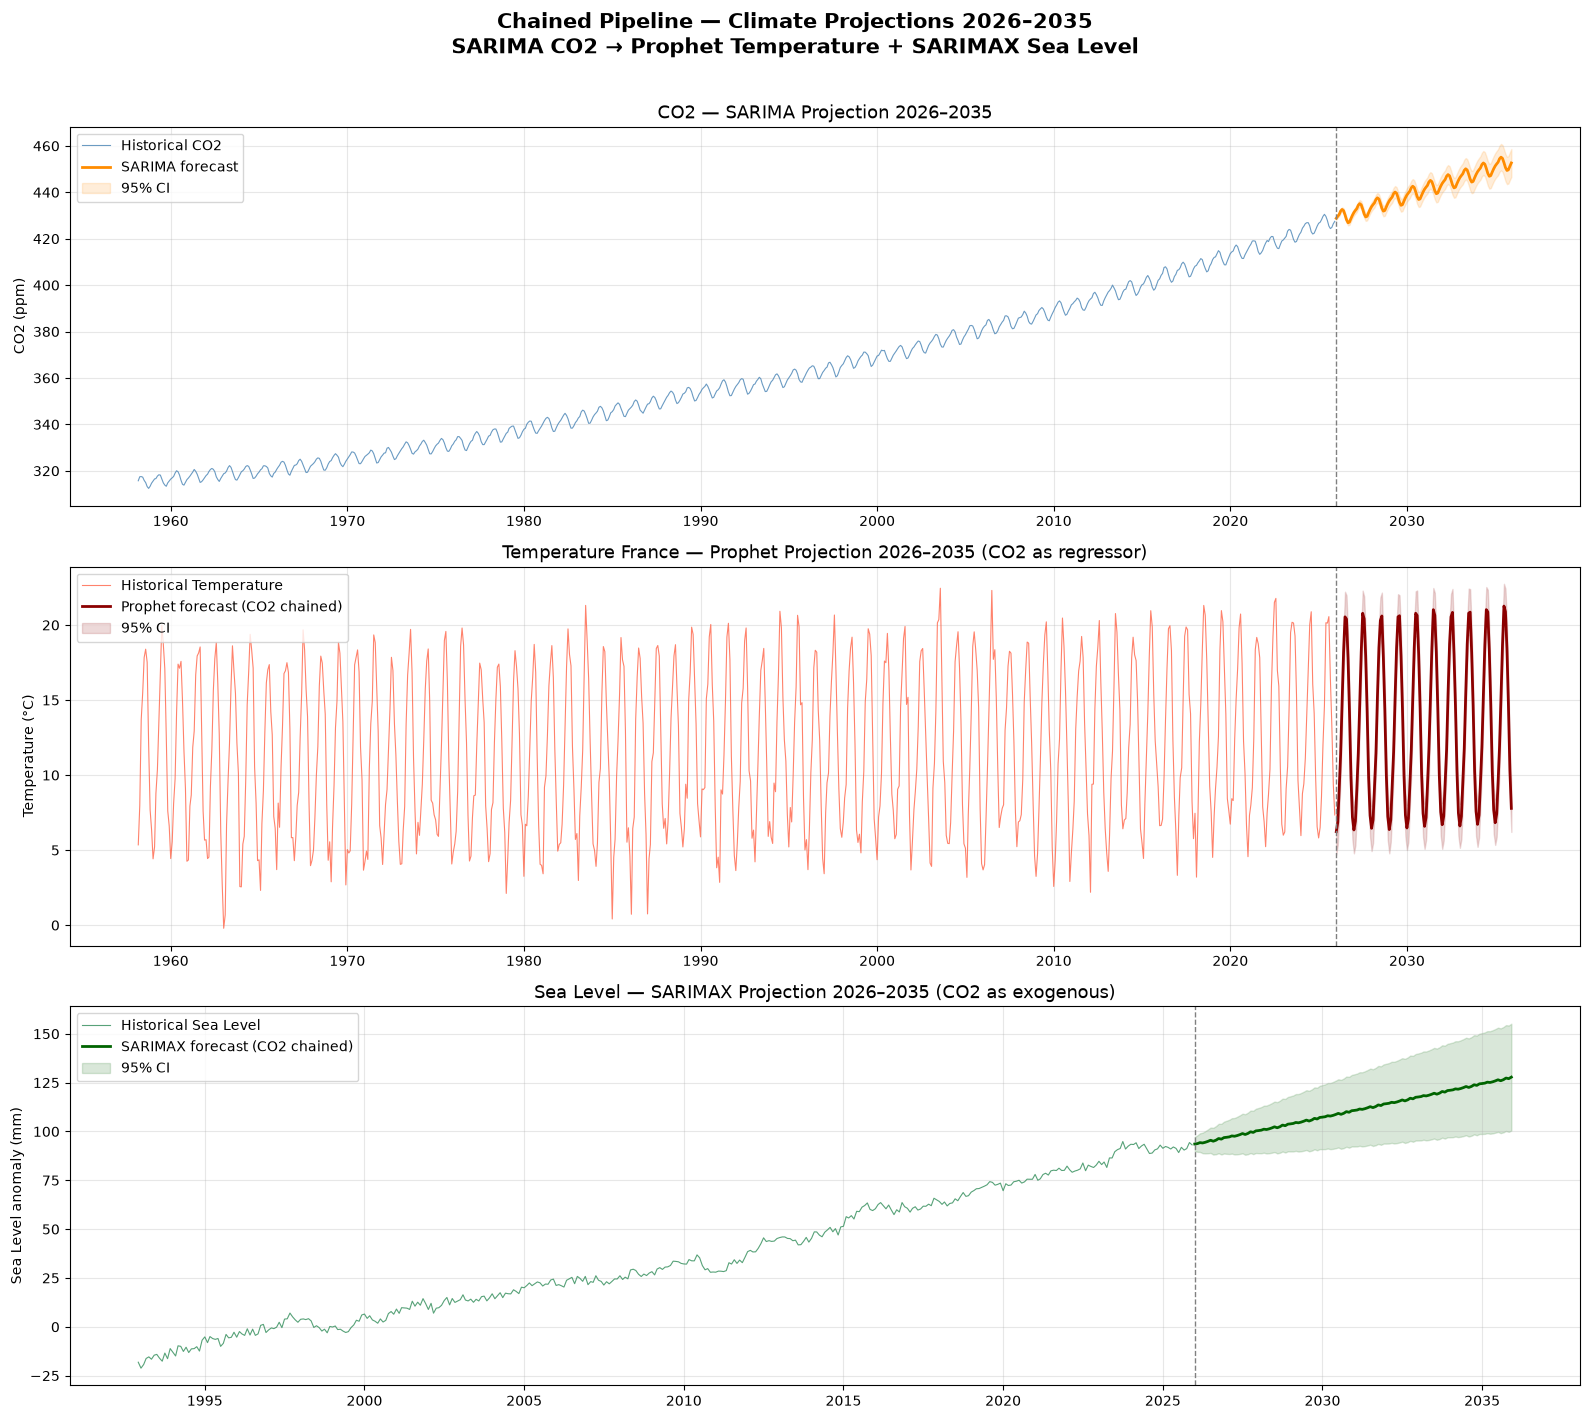

In [176]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)
HIST_ALPHA = 0.8
CI_ALPHA   = 0.15
CUT = pd.Timestamp("2026-01-01")

# CO2 panel
ax = axes[0]
ax.plot(co2_full.index, co2_full.values,
        color="steelblue", linewidth=0.8, alpha=HIST_ALPHA, label="Historical CO2")
ax.plot(future_index, co2_future.values,
        color="darkorange", linewidth=2, label="SARIMA forecast")
ax.fill_between(future_index, co2_ci.iloc[:, 0], co2_ci.iloc[:, 1],
                color="darkorange", alpha=CI_ALPHA, label="95% CI")
ax.axvline(CUT, color="gray", linestyle="--", linewidth=1)
ax.set_title("CO2 — SARIMA Projection 2026–2035", fontsize=13)
ax.set_ylabel("CO2 (ppm)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# temperature panel
ax2 = axes[1]
ax2.plot(df_pipe_temp.index, df_pipe_temp["temp_celsius"],
         color="tomato", linewidth=0.8, alpha=HIST_ALPHA, label="Historical Temperature")
ax2.plot(future_index, temp_future.values,
         color="darkred", linewidth=2, label="Prophet forecast (CO2 chained)")
ax2.fill_between(future_index, temp_future_lower, temp_future_upper,
                 color="darkred", alpha=CI_ALPHA, label="95% CI")
ax2.axvline(CUT, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Temperature France — Prophet Projection 2026–2035 (CO2 as regressor)", fontsize=13)
ax2.set_ylabel("Temperature (°C)")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

# sea level panel
ax3 = axes[2]
ax3.plot(sl_full.index, sl_full.values,
         color="seagreen", linewidth=0.8, alpha=HIST_ALPHA, label="Historical Sea Level")
ax3.plot(future_index, sl_future.values,
         color="darkgreen", linewidth=2, label="SARIMAX forecast (CO2 chained)")
ax3.fill_between(future_index, sl_ci.iloc[:, 0], sl_ci.iloc[:, 1],
                 color="darkgreen", alpha=CI_ALPHA, label="95% CI")
ax3.axvline(CUT, color="gray", linestyle="--", linewidth=1)
ax3.set_title("Sea Level — SARIMAX Projection 2026–2035 (CO2 as exogenous)", fontsize=13)
ax3.set_ylabel("Sea Level anomaly (mm)")
ax3.legend(loc="upper left")
ax3.grid(alpha=0.3)

plt.suptitle("Chained Pipeline — Climate Projections 2026–2035\n"
             "SARIMA CO2 → Prophet Temperature + SARIMAX Sea Level",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Key projections summary

In [177]:
yr2030_co2  = co2_future.loc["2030"].mean()
yr2035_co2  = co2_future.loc["2035"].mean()
yr2025_co2  = co2_full.loc["2025"].mean()

yr2030_temp = temp_future.loc["2030"].mean()
yr2035_temp = temp_future.loc["2035"].mean()
yr2025_temp = df_temp.loc["2025"].mean()

yr2030_sl   = sl_future.loc["2030"].mean()
yr2035_sl   = sl_future.loc["2035"].mean()
yr2025_sl   = sl_full.loc["2025"].mean()

print(f"{'':<30} {'2025':>14} {'2030':>16} {'2035':>16}")
print("=" * 78)
print(f"{'CO2 (ppm)':<30} {yr2025_co2:>14.1f} {yr2030_co2:>16.1f} {yr2035_co2:>16.1f}")
print(f"{'Temperature France (°C)':<30} {yr2025_temp:>14.2f} {yr2030_temp:>16.2f} {yr2035_temp:>16.2f}")
print(f"{'Sea Level anomaly (mm)':<30} {yr2025_sl:>14.1f} {yr2030_sl:>16.1f} {yr2035_sl:>16.1f}")
print()
print(f"CO2   +{yr2035_co2 - yr2025_co2:.1f} ppm over 10 years")
print(f"Temp  +{yr2035_temp - yr2025_temp:.2f}°C over 10 years")
print(f"SL    +{yr2035_sl - yr2025_sl:.1f} mm over 10 years")

                                  2025 (actual)   2030 (projected)   2035 (projected)
CO2 (ppm)                                 427.3              439.8              452.3
Temperature France (°C)                   12.90              13.27              13.57
Sea Level anomaly (mm)                     91.7              108.8              126.0

  CO2 increase  2025→2035 : +24.9 ppm
  Temp increase 2025→2035 : +0.68 °C
  Sea level rise 2025→2035: +34.3 mm


### 6.6 Detailed predictions — May / June / July 2026

In [178]:
# extract predictions for May, June, July 2026
target_months = ["2026-05", "2026-06", "2026-07"]
month_labels  = ["May 2026", "June 2026", "July 2026"]

print(f"{'Month':<14} {'CO2 (ppm)':>12} {'Temp (°C)':>12} {'95% CI':>20} {'Sea Level (mm)':>16}")
print("=" * 78)
for label, m in zip(month_labels, target_months):
    co2_val  = co2_future.loc[m].values[0]
    temp_val = temp_future.loc[m].values[0]
    temp_lo  = temp_future_lower.loc[m].values[0]
    temp_hi  = temp_future_upper.loc[m].values[0]
    sl_val   = sl_future.loc[m].values[0]
    print(f"{label:<14} {co2_val:>12.2f} {temp_val:>12.2f} {f'[{temp_lo:.2f} – {temp_hi:.2f}]':>20} {sl_val:>16.1f}")

Month             CO2 (ppm)    Temp (°C)  Temp CI low  Temp CI high   Sea Level (mm)
May 2026             432.62        14.79        13.12         16.32             94.5
June 2026            432.09        18.21        16.86         19.78             94.9
July 2026            430.29        20.54        19.03         22.22             95.5


In [179]:
# compare with the same months in recent years
print("historical reference (same months, recent years) :")
print(f"{'Month':<14} {'Temp (°C)':>12}")
print("-" * 28)
for year in [2022, 2023, 2024, 2025]:
    for month, label in zip([5, 6, 7], ["May", "Jun", "Jul"]):
        try:
            val = df_temp.loc[f"{year}-{month:02d}"]
            print(f"{label} {year:<9} {val:>12.2f}")
        except:
            pass


Historical reference (same months, recent years):
Month             Temp (°C)
----------------------------


## 7. Final Visualization — Full Summary

One combined chart: historical data + projections for all 3 variables.

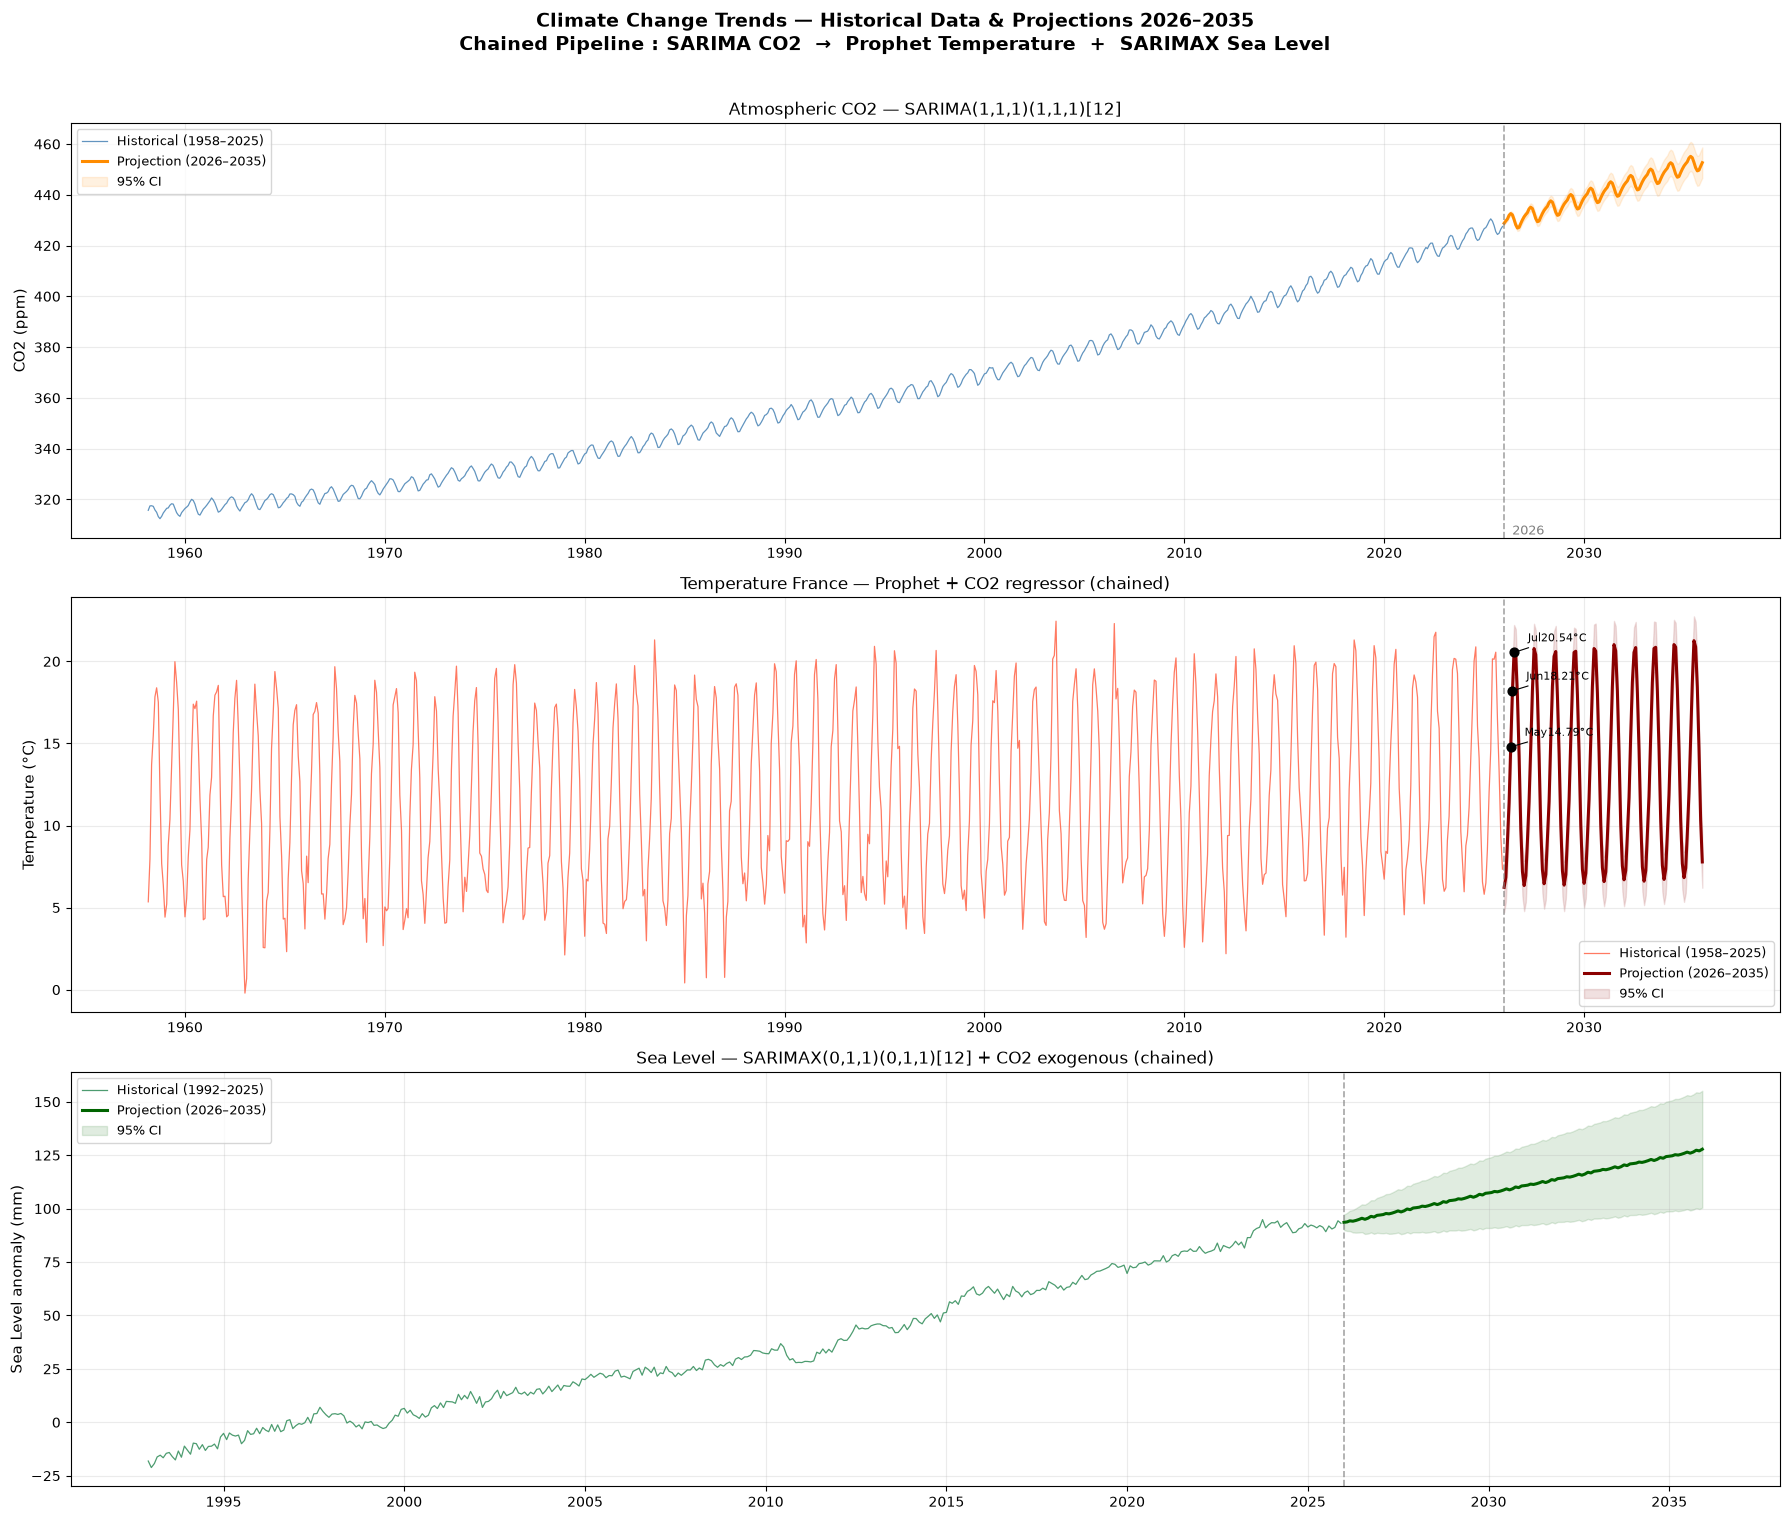

In [180]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

HIST_COLOR  = {"co2": "steelblue", "temp": "tomato",    "sl": "seagreen"}
PROJ_COLOR  = {"co2": "darkorange","temp": "darkred",   "sl": "darkgreen"}
CI_ALPHA    = 0.12
CUT         = pd.Timestamp("2026-01-01")

# CO2
ax1 = axes[0]
ax1.plot(co2_full.index, co2_full.values,
         color=HIST_COLOR["co2"], linewidth=0.9, alpha=0.85, label="Historical (1958–2025)")
ax1.plot(future_index, co2_future.values,
         color=PROJ_COLOR["co2"], linewidth=2.2, label="Projection (2026–2035)")
ax1.fill_between(future_index, co2_ci.iloc[:, 0], co2_ci.iloc[:, 1],
                 color=PROJ_COLOR["co2"], alpha=CI_ALPHA, label="95% CI")
ax1.axvline(CUT, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax1.text(CUT, ax1.get_ylim()[0], "  2026", color="gray", fontsize=9, va="bottom")
ax1.set_ylabel("CO2 (ppm)", fontsize=11)
ax1.set_title("Atmospheric CO2 — SARIMA(1,1,1)(1,1,1)[12]", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

# temperature
ax2 = axes[1]
ax2.plot(df_pipe_temp.index, df_pipe_temp["temp_celsius"],
         color=HIST_COLOR["temp"], linewidth=0.9, alpha=0.85, label="Historical (1958–2025)")
ax2.plot(future_index, temp_future.values,
         color=PROJ_COLOR["temp"], linewidth=2.2, label="Projection (2026–2035)")
ax2.fill_between(future_index, temp_future_lower, temp_future_upper,
                 color=PROJ_COLOR["temp"], alpha=CI_ALPHA, label="95% CI")
# mark May/Jun/Jul 2026 on the chart
for m, label in zip(["2026-05","2026-06","2026-07"], ["May","Jun","Jul"]):
    ts  = pd.Timestamp(m)
    val = temp_future.loc[m].values[0]
    ax2.scatter(ts, val, color="black", zorder=5, s=40)
    ax2.annotate(f"{label}{val:.2f}°C", xy=(ts, val),
                 xytext=(10, 8), textcoords="offset points", fontsize=8,
                 arrowprops=dict(arrowstyle="-", color="black", lw=0.8))
ax2.axvline(CUT, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax2.set_ylabel("Temperature (°C)", fontsize=11)
ax2.set_title("Temperature France — Prophet + CO2 regressor (chained)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

# sea level
ax3 = axes[2]
ax3.plot(sl_full.index, sl_full.values,
         color=HIST_COLOR["sl"], linewidth=0.9, alpha=0.85, label="Historical (1992–2025)")
ax3.plot(future_index, sl_future.values,
         color=PROJ_COLOR["sl"], linewidth=2.2, label="Projection (2026–2035)")
ax3.fill_between(future_index, sl_ci.iloc[:, 0], sl_ci.iloc[:, 1],
                 color=PROJ_COLOR["sl"], alpha=CI_ALPHA, label="95% CI")
ax3.axvline(CUT, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax3.set_ylabel("Sea Level anomaly (mm)", fontsize=11)
ax3.set_title("Sea Level — SARIMAX(0,1,1)(0,1,1)[12] + CO2 exogenous (chained)", fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)

plt.suptitle(
    "Climate Change Trends — Historical Data & Projections 2026–2035\n"
    "Chained Pipeline : SARIMA CO2  →  Prophet Temperature  +  SARIMAX Sea Level",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

In [181]:
# compare same months from recent years with our 2026 predictions
print("historical reference (same months, recent years) :")
print(f"{'Month':<14} {'Temp (°C)':>10}")
print("-" * 26)
for year in [2022, 2023, 2024, 2025]:
    for month, label in zip([5, 6, 7], ["May", "Jun", "Jul"]):
        mask = (df_temp.index.year == year) & (df_temp.index.month == month)
        vals = df_temp[mask]
        if len(vals):
            print(f"{label} {year:<9} {vals.values[0]:>10.2f}")

print()
print("pipeline predictions (2026) :")
print(f"{'Month':<14} {'Temp (°C)':>10} {'95% CI':>20}")
print("-" * 46)
for m, label in zip(["2026-05","2026-06","2026-07"], ["May 2026","Jun 2026","Jul 2026"]):
    val = temp_future.loc[m].values[0]
    lo  = temp_future_lower.loc[m].values[0]
    hi  = temp_future_upper.loc[m].values[0]
    print(f"{label:<14} {val:>10.2f} {f'[{lo:.2f} – {hi:.2f}]':>20}")

Historical reference (same months, recent years):
Month           Temp (°C)
--------------------------
May 2022           15.88
Jun 2022           19.18
Jul 2022           21.51
May 2023           14.40
Jun 2023           19.49
Jul 2023           20.18
May 2024           14.13
Jun 2024           17.15
Jul 2024           20.02
May 2025           14.61
Jun 2025           20.15
Jul 2025           20.13

Pipeline predictions (2026) :
Month           Temp (°C)               95% CI
----------------------------------------------
May 2026            14.79      [13.12 – 16.32]
Jun 2026            18.21      [16.86 – 19.78]
Jul 2026            20.54      [19.03 – 22.22]
